# 분석 목표
이 노트북은 동일한 급탕 사용 스케줄과 실외 온도 조건에서 GasBoiler와 AirSourceHeatPumpBoiler의 동적 시뮬레이션을 수행하고, 각 나라의 현재 전력 믹스를 기반으로 Well-to-tap 분석을 통해 CO2 배출량, Primary energy use, 엑서지 효율, 에너지 효율을 타임시리즈로 분석합니다.

- 동적 시뮬레이션 기반 타임시리즈 분석
- 나라별 전력 믹스에 따른 CO2 배출량 비교
- Primary Energy 사용량 비교
- 엑서지 효율 및 에너지 효율 비교
- 일일 적분값 비교

# 1. Ready

## 1.1 Import library

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append('../../src')
sys.path.append('.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec

import dartwork_mpl as dm
import enex_analysis as enex
from tqdm import tqdm
import CoolProp as CP
import cv2

dm.style.stack(['dmpl_light'])

from enex_analysis.GasBoiler import GasBoiler
from enex_analysis.AirSourceHeatPumpBoiler import AirSourceHeatPumpBoiler

from enex_analysis.constants import c_a, c_w, rho_a, rho_w
from enex_analysis.enex_functions import *

print("Libraries imported successfully!")

Libraries imported successfully!


## 1.2 font 

In [2]:
plt.rcParams['font.size'] = 9

fs = {
    'label': dm.fs(0),
    'tick': dm.fs(-1.0),
    'legend': dm.fs(-1.5),
    'subtitle': dm.fs(-0.5),
    'cbar_tick': dm.fs(-1.5),
    'cbar_label': dm.fs(-1.5),
    'cbar_title': dm.fs(-1),
    'setpoint': dm.fs(-1),
    'text': dm.fs(-2.0),
            }

pad = {
    'label': 6,
    'tick': 5,
}

=== 현재 matplotlib 폰트 설정 ===
font.family: ['roboto']
font.serif: ['DejaVu Serif', 'Bitstream Vera Serif', 'Computer Modern Roman', 'New Century Schoolbook', 'Century Schoolbook L', 'Utopia', 'ITC Bookman', 'Bookman', 'Nimbus Roman No9 L', 'Times New Roman', 'Times', 'Palatino', 'Charter', 'serif']
font.sans-serif: ['DejaVu Sans', 'Bitstream Vera Sans', 'Computer Modern Sans Serif', 'Lucida Grande', 'Verdana', 'Geneva', 'Lucid', 'Arial', 'Helvetica', 'Avant Garde', 'sans-serif']
mathtext.fontset: custom

=== 수식 폰트 정보 ===
Default font: Roboto

=== 폰트 'roboto' 이탤릭 지원 확인 ===
폰트 변형: ['Roboto', 'Roboto', 'Roboto', 'Roboto', 'Roboto', 'Roboto', 'Roboto', 'Roboto', 'Roboto', 'Roboto']

=== 수식 렌더링 폰트 ===
mathtext.fontset: custom

테스트 이미지가 저장되었습니다: /tmp/italic_test.png

=== 폰트 파일 경로 ===
Roboto: /home/habin/Codes/enex_analysis_engine/.venv/lib/python3.11/site-packages/dartwork_mpl/asset/font/Roboto-Regular.ttf
  파일 존재: True


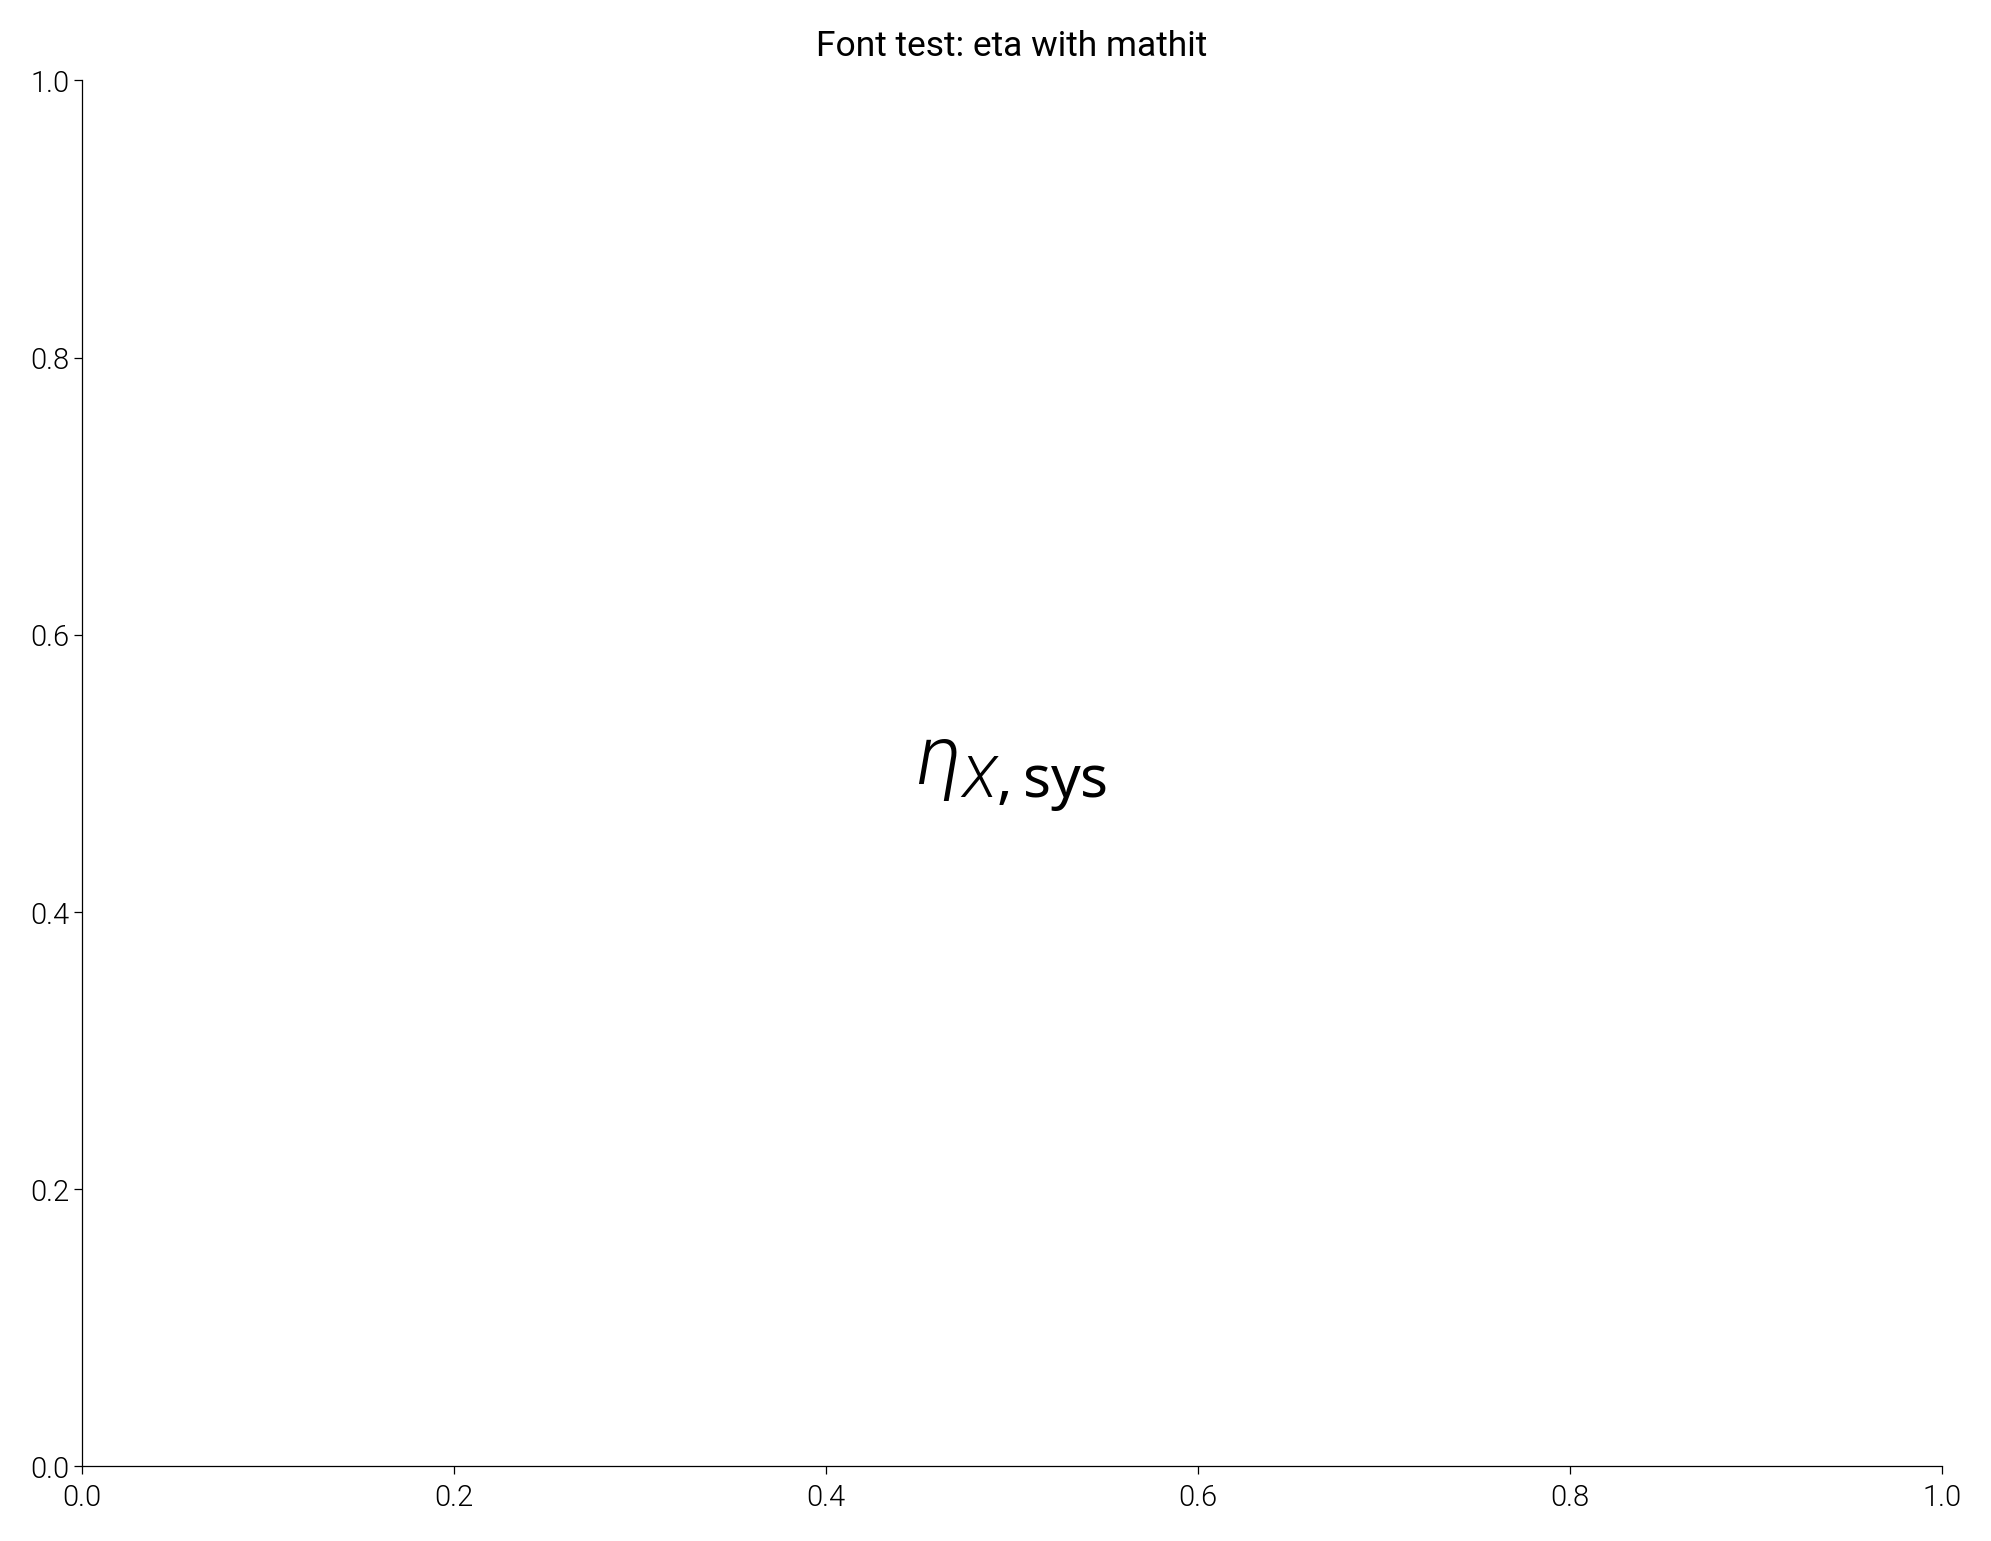

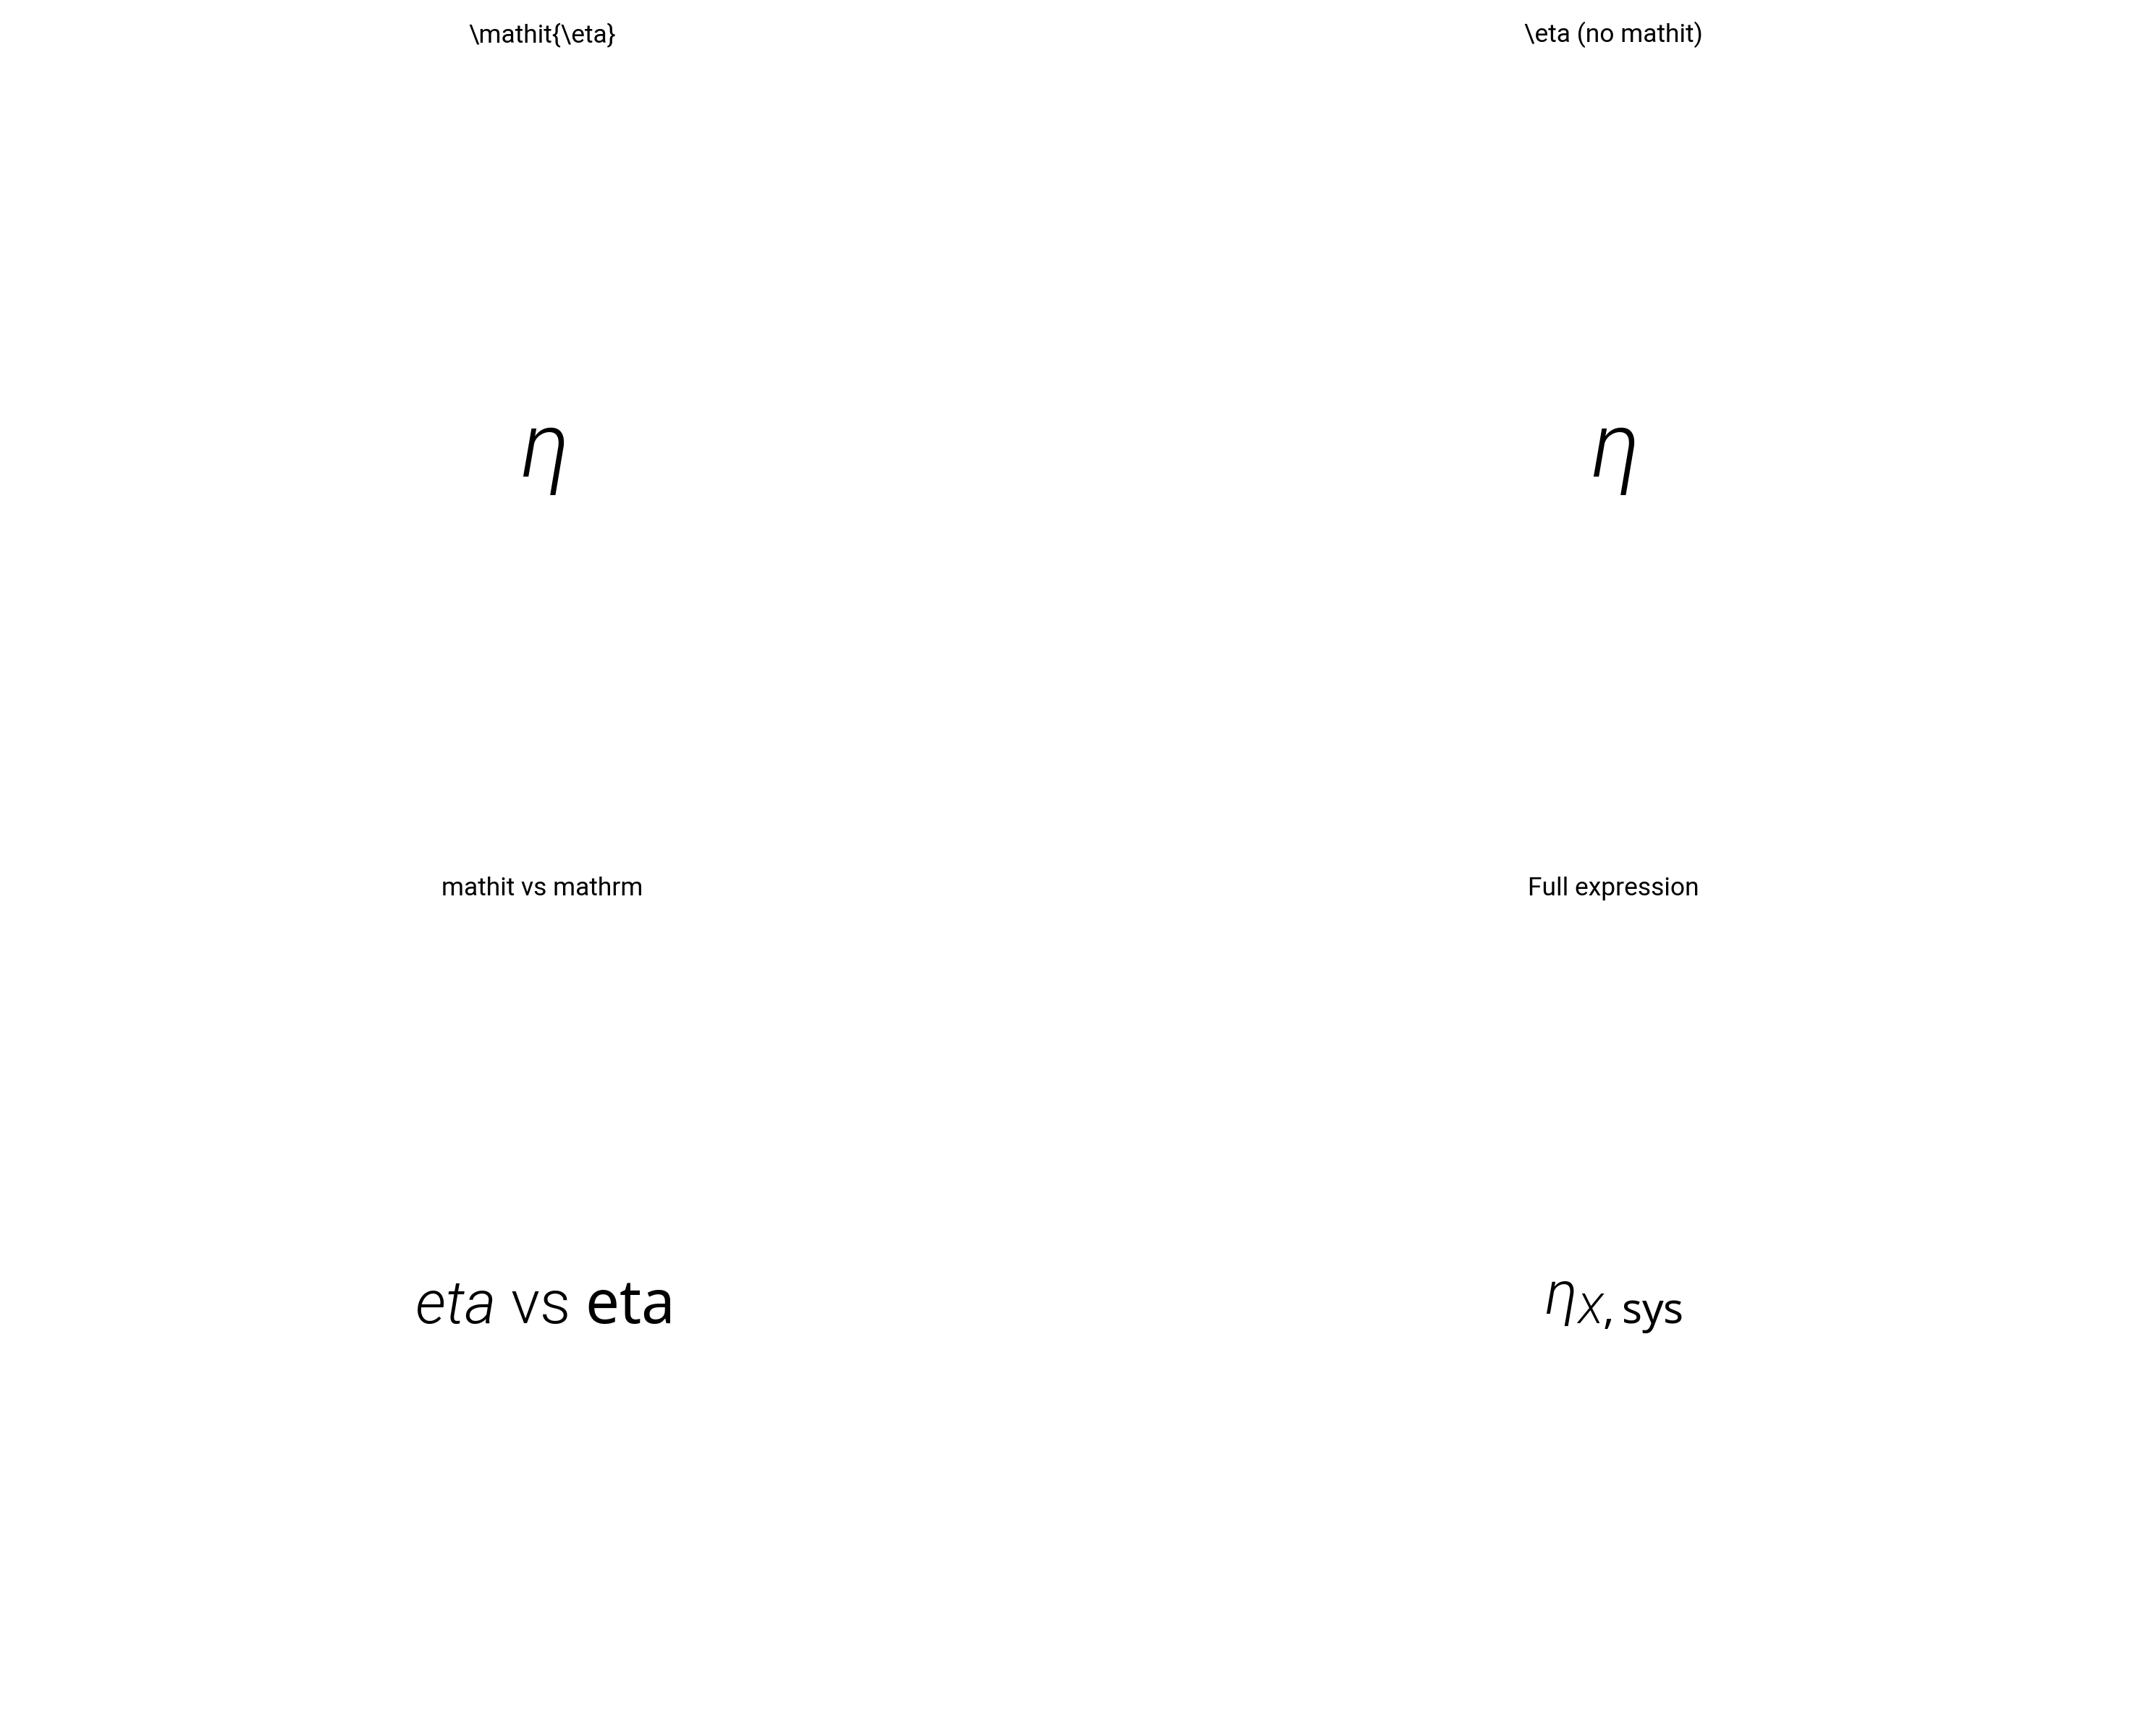

In [3]:
# 현재 matplotlib 폰트 설정 확인
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt


# custom 폰트셋을 유지하면서 이탤릭 지원 활성화
plt.rcParams['mathtext.fontset'] = 'custom'
# 수식용 이탤릭 폰트를 명시적으로 설정
plt.rcParams['mathtext.it'] = 'Roboto:italic'  # Roboto Italic 사용


# 1. 현재 사용 중인 폰트 정보 확인
print("=== 현재 matplotlib 폰트 설정 ===")
print(f"font.family: {plt.rcParams['font.family']}")
print(f"font.serif: {plt.rcParams['font.serif']}")
print(f"font.sans-serif: {plt.rcParams['font.sans-serif']}")
print(f"mathtext.fontset: {plt.rcParams['mathtext.fontset']}")

# 2. 실제 렌더링에 사용되는 폰트 확인
fig, ax = plt.subplots(figsize=(8, 6))
ax.text(0.5, 0.5, r'$\mathit{\eta}_{X,\mathrm{sys}}$', fontsize=20, ha='center', va='center')
ax.set_title('Font test: eta with mathit')
plt.savefig('/tmp/font_test.png', dpi=150)

# 3. 수식 모드에서 사용되는 폰트 확인
print("\n=== 수식 폰트 정보 ===")
prop = fm.FontProperties()
print(f"Default font: {prop.get_name()}")

# 4. 현재 폰트가 이탤릭을 지원하는지 확인
current_font_name = plt.rcParams.get('font.family', ['sans-serif'])[0]
if isinstance(current_font_name, list):
    current_font_name = current_font_name[0]

print(f"\n=== 폰트 '{current_font_name}' 이탤릭 지원 확인 ===")
available_fonts = [f.name for f in fm.fontManager.ttflist]
italic_variants = [f for f in available_fonts if 'italic' in f.lower() or 'oblique' in f.lower()]

# 현재 폰트의 이탤릭 변형 확인
font_variants = [f for f in available_fonts if current_font_name.lower() in f.lower()]
print(f"폰트 변형: {font_variants[:10]}")  # 처음 10개만 표시

# 5. 수식에서 사용 가능한 폰트 확인
print("\n=== 수식 렌더링 폰트 ===")
math_font = plt.rcParams.get('mathtext.fontset', 'dejavusans')
print(f"mathtext.fontset: {math_font}")

# 6. 직접 이탤릭 테스트
fig2, axes = plt.subplots(2, 2, figsize=(10, 8))

# 테스트 1: \mathit 사용
axes[0, 0].text(0.5, 0.5, r'$\mathit{\eta}$', fontsize=30, ha='center', va='center')
axes[0, 0].set_title('\\mathit{\\eta}')

# 테스트 2: 일반 eta
axes[0, 1].text(0.5, 0.5, r'$\eta$', fontsize=30, ha='center', va='center')
axes[0, 1].set_title('\\eta (no mathit)')

# 테스트 3: \mathit과 일반 텍스트 비교
axes[1, 0].text(0.5, 0.5, r'$\mathit{eta}$ vs $\mathrm{eta}$', fontsize=20, ha='center', va='center')
axes[1, 0].set_title('mathit vs mathrm')

# 테스트 4: 전체 수식
axes[1, 1].text(0.5, 0.5, r'$\mathit{\eta}_{X,\mathrm{sys}}$', fontsize=20, ha='center', va='center')
axes[1, 1].set_title('Full expression')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.savefig('/tmp/italic_test.png', dpi=150)
print("\n테스트 이미지가 저장되었습니다: /tmp/italic_test.png")

# 7. 폰트가 실제로 이탤릭을 지원하는지 파일 시스템에서 확인
import os
font_paths = {}
for font in fm.fontManager.ttflist:
    if current_font_name.lower() in font.name.lower():
        if font.name not in font_paths:
            font_paths[font.name] = font.fname

print(f"\n=== 폰트 파일 경로 ===")
for name, path in list(font_paths.items())[:5]:
    print(f"{name}: {path}")
    if os.path.exists(path):
        # ttf 파일에서 이탤릭 스타일 확인 (ttx 도구가 있으면 더 자세히 확인 가능)
        print(f"  파일 존재: True")

## 1.3 Path

In [4]:
result_path = '../result/'
data_path = '../data/'

# 2. Simulation parameter setting

## 2.1 Simulation time

In [42]:
# 시뮬레이션 파라미터 설정
simulation_period_sec = 24 * enex.h2s  # 24시간
dt_s = 60  # 60 초
tN = int(simulation_period_sec / dt_s) # time step number
time_s = np.arange(tN + 1) * dt_s
time_s = time_s[:-1]
time_h = time_s * enex.s2h

## 2.3 Schedule data import
The files(s) included in this zip-file are part of the set of data files that comes with the IEA Annex 42 report "European and Canadian non-HVAC Electric and DHW Load Profiles for Use in Simulating the Performance of Residential Cogeneration Systems". Copies of this report and the full set of data files may be obtained from the Annex 42 web site at: www.cogen-sim.net or from the IEA/ECBCS Bookshop at: www.ecbcs.org. See the above mentioned report for a detailed description of the profiles contained in this zip-file.


In [6]:
# Water use schedule
main_header_row = 2
schedule_DB = pd.read_excel(data_path + 'Annex_42_DHW_profiles.xls', sheet_name=None,header=main_header_row)
Lph_200L_1min_scale_df = schedule_DB['1 minute data - 200l per day']

date = '2025-01-01'
month = 'Jan'
day = 1

# Jan_1st_time_df = Lph_200L_1min_scale_df.loc[:One_day_to_min*day-1,:'Minute']
One_day_to_min = 24 * enex.h2m
Jan_1st_df = Lph_200L_1min_scale_df.loc[One_day_to_min*(day-1):One_day_to_min*day-1, month]

# 3. 단위 변환 (L/hour -> L/min)
# 사용자 요청에 따라 원본이 L/hour라고 가정하고 60으로 나눔
flow_lpm = Jan_1st_df / enex.h2m # [L/min] -> [L/min]

# 4. Peak 유량 산출 (Fraction = 1.0 기준값)
peak_flow_lpm = flow_lpm.max()

# 5. 스케줄 리스트 생성
schedule_entries = []
for i, flow in enumerate(flow_lpm):
    hour = i // 60
    minute = i % 60
    
    # 시작 시간 문자열
    start_time = f"{hour}:{minute:02d}"
    
    # 종료 시간 계산 (다음 분)
    next_min_total = i + 1
    end_hour = next_min_total // 60
    end_minute = next_min_total % 60
    
    # 24:00 처리
    if end_hour == 24:
        end_time = "24:00"
    else:
        end_time = f"{end_hour}:{end_minute:02d}"
    
    # Fraction 계산 (소수점 4자리 반올림)
    fraction = round(flow / peak_flow_lpm, 4) if peak_flow_lpm > 0 else 0.0
    
    # 유량이 있는 구간만 추가하거나, 전체를 추가할 수 있음
    # 여기서는 포맷 예시를 위해 전체 추가
    schedule_entries.append((start_time, end_time, fraction))

# Weather data
Seoul_25_T0_df = pd.read_csv(data_path + 'Seoul_25_T0_avg.csv' , encoding='cp949')
Seoul_250101_T0 = pd.read_csv(data_path + 'Seoul_250101_T0.csv', encoding='cp949')
Seoul_250401_T0 = pd.read_csv(data_path + 'Seoul_250401_T0.csv', encoding='cp949')
Seoul_250801_T0 = pd.read_csv(data_path + 'Seoul_250801_T0.csv', encoding='cp949')
Seoul_251101_T0 = pd.read_csv(data_path + 'Seoul_251101_T0.csv', encoding='cp949')

## 2.3 Common params

In [7]:

# 10.1016/j.energy.2021.120678 한국 가정용
# 이 연구는 경기도 성남시에 위치한 지역난방 아파트 단지 918세대를 대상으로 데이터를 수집
# 계절에 따른 사용량 차이가 매우 뚜렷하게 나타납니다.
total_use_water_L = 270 

# schedule_entries = process_dhw_schedule_from_Annex_42(Lph_200L_1min_scale_df)
sum_frac = sum([entry[2] for entry in schedule_entries])
peak_flow_lpm = total_use_water_L / sum_frac
dV_w_serv_m3s = peak_flow_lpm * enex.L2m3 / enex.m2s
calc_total_water_use_from_schedule(schedule_entries, dV_w_serv_m3s, info = False, info_unit='mL')

ref          = 'R134a'
V_disp_cmp   = 0.0002
eta_cmp_isen = 0.8

# 열교환기 파라미터 (상수 UA)
UA_cond_design = 2000.0 
UA_evap_design = 1000.0
A_cross_ou     = np.pi * 0.25 ** 2

# 실외기 팬 파라미터 (정풍량)
dV_ou_design      = 1.5
dP_ou_design      = 90.0
eta_fan_ou_design = 0.6

T0_schedule = Seoul_250101_T0.loc[Seoul_250101_T0['지점명'] == '서울', '기온(°C)'].values # 지점명이 관악산도 껴있어서 전처리
T_serv_w = 40.0
T_sup_w = calc_cold_water_temp(Seoul_25_T0_df, date)

T_tank_w_init = 65.0
T_tank_w_lower_bound = 60.0
T_tank_w_upper_bound = 65.0 

heater_capacity = 15000.0

# T0_schedule
r0 = 0.2      # [m]
H = 1.2       # [m]
x_shell = 0.005
x_ins   = 0.05
k_shell = 25
k_ins   = 0.03
h_o     = 15
tank_V = np.pi * r0**2 * H     # m³
print(f"저탕조 체적: {tank_V*1000:.1f} L")
print(f"상수도 온도: {T_sup_w:.1f} °C")

저탕조 체적: 150.8 L
상수도 온도: 10.9 °C


# 3. Simulation

## 3.1 Scenario 1. UV lamp
> **변화시킬 것**: 저탕조 저장수 온도 로직(온도 유지 범위)과 UV 램프의 적용(저탕조 크기에 따라 필요한 모델의 정격출력은 얼마인지, 운전 로직은 어떻게 되는지)
> 
> **제약 변수**: 나머지 모든 변수
> 
> **관찰할 것**: 시스템 COP의 변화와, 전력 사용량의 누적 변화

### 3.1.1 UV NO
UV를 없애고, 저탕조 upper, lower bound 온도를 45~55 °C로

In [97]:
hpb = AirSourceHeatPumpBoiler(
    # 냉매/사이클/압축기 파라미터
    ref          = ref,
    V_disp_cmp   = V_disp_cmp,
    eta_cmp_isen = eta_cmp_isen,
    
    # 열교환기 파라미터 (상수 UA)
    UA_cond_design = UA_cond_design,              # 응축기 열전달 계수 [W/K] (상수) -> 키우면 LMTD가 작아짐
    UA_evap_design = UA_evap_design,             # 증발기 열전달 계수 [W/K] (상수)
    A_cross_ou     = A_cross_ou,   # 실외기 공기 토출 단면적 [m²]
    
    # 실외기 팬 파라미터 (정풍량)
    dV_ou_design      = dV_ou_design,       # 실외기 설계 풍량 [m³/s] (정풍량)
    dP_ou_design      = dP_ou_design,   # 실외기 설계 정압 [Pa]
    eta_fan_ou_design = eta_fan_ou_design,
    
    # 탱크/제어/부하 파라미터
    T_tank_w_upper_bound    = T_tank_w_upper_bound,      # 저탕조 설정 온도 [°C]
    T_tank_w_lower_bound = T_tank_w_lower_bound,      # 저탕조 하한 온도 [°C]
    T_serv_w             = T_serv_w,      # 서비스 급탕 온도 [°C]
    T_sup_w              = T_sup_w,      # 급수(상수도) 온도 [°C]
    heater_capacity      = heater_capacity,   # 히터 최대 용량 [W]
    dV_w_serv_m3s        = dV_w_serv_m3s,    # 최대 급탕 유량 [m³/s]
    
    r0      = r0,    # 탱크 반지름 [m]
    H       = H,    # 탱크 높이 [m]
    x_shell = x_shell,   # 탱크 외벽 두께 [m]
    x_ins   = x_ins,   # 단열재 두께 [m]
    k_shell = k_shell,     # 탱크 외벽 열전도도 [W/mK]
    k_ins   = k_ins,   # 단열재 열전도도 [W/mK]
    h_o     = h_o,     # 외부 대류 열전달계수 [W/m²K]
)
hpb.analyze_dynamic(
    simulation_period_sec = simulation_period_sec,
    dt_s                  = dt_s,
    T_tank_w_init_C       = T_tank_w_init,
    schedule_entries      = schedule_entries,
    T0_schedule           = T0_schedule,
    result_save_csv_path  = result_path + 'hpb_UV_NO.csv'
)

ASHPB Simulating:   0%|          | 0/1440 [00:00<?, ?it/s]

ASHPB Simulating: 100%|██████████| 1440/1440 [00:39<00:00, 36.39it/s] 


,is_on,converged,T_a_ou_in [°C],T_a_ou_out [°C],T1 [°C],T2 [°C],T3 [°C],T4 [°C],T_cond [°C],T_tank_w [°C],...,E_tot [W],X_fan_ou [W],X_tot [W],fan_eff [%],is_transitioning,Q_tank_loss [W],cop_ref [-],cop_sys [-],X_eff_ref [%],X_eff_sys [%]
0,False,True,0.0,0.0,NaN,NaN,NaN,NaN,0.0,65.000000,...,0.0,0.0,0.0,0.0,False,75.817672,0.0,0.0,0.0,0.0
1,False,True,0.0,0.0,NaN,NaN,NaN,NaN,0.0,64.992793,...,0.0,0.0,0.0,0.0,False,75.809419,0.0,0.0,0.0,0.0
2,False,True,0.0,0.0,NaN,NaN,NaN,NaN,0.0,64.985588,...,0.0,0.0,0.0,0.0,False,75.801166,0.0,0.0,0.0,0.0
3,False,True,0.0,0.0,NaN,NaN,NaN,NaN,0.0,64.978383,...,0.0,0.0,0.0,0.0,False,75.792914,0.0,0.0,0.0,0.0
4,False,True,0.0,0.0,NaN,NaN,NaN,NaN,0.0,64.971178,...,0.0,0.0,0.0,0.0,False,75.784663,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,False,True,0.0,0.0,-25.130258,89.639739,65.52362,-25.130258,0.0,63.182325,...,0.0,0.0,0.0,0.0,False,71.445358,0.0,0.0,0.0,0.0
1436,False,True,0.0,0.0,-25.130258,89.639739,65.52362,-25.130258,0.0,63.175534,...,0.0,0.0,0.0,0.0,False,71.437580,0.0,0.0,0.0,0.0
1437,False,True,0.0,0.0,-25.130258,89.639739,65.52362,-25.130258,0.0,63.168744,...,0.0,0.0,0.0,0.0,False,71.429803,0.0,0.0,0.0,0.0
1438,False,True,0.0,0.0,-25.130258,89.639739,65.52362,-25.130258,0.0,63.161954,...,0.0,0.0,0.0,0.0,False,71.536556,0.0,0.0,0.0,0.0


In [96]:
# 모든 converged 컬럼이 수렴하였는지 검토 후 프린트문 작성
hpb_uv_no = pd.read_csv(result_path + 'hpb_UV_NO.csv')

converged_all = hpb_uv_no['converged'].all()
print("="*40)
print(f"[수렴 여부] All converged: {converged_all}")
if not converged_all:
    nonconverged_count = (~hpb_uv_no['converged']).sum()
    print(f"  - 미수렴 데이터 수: {nonconverged_count} / {len(hpb_uv_no)}")
    print(hpb_uv_no[hpb_uv_no['converged'] == False])
print("="*40)

# Fan 전력 투입률은 compressor 전력투입률의 약 5~10% 수준으로 검증
fan_power_pct = ((hpb_uv_no['E_fan_ou [W]'].sum() * dt_s)/ (hpb_uv_no['E_tot [W]'].sum() * dt_s)) * 100
print(f"[Fan 전력 투입률] {fan_power_pct:.1f}%   (일반: 5~10%)")
print("="*40)

# fan 평균 풍량이 설계풍량 대비 몇 %인지 프린트
fan_nonzero = hpb_uv_no.loc[hpb_uv_no['dV_fan_ou [m3/s]'] != 0, 'dV_fan_ou [m3/s]']
fan_avg_flow = fan_nonzero.mean()
fan_avg_flow_pct = (fan_avg_flow / dV_ou_design) * 100
print("[Fan 평균 풍량]")
print(f"  - 평균 풍량: {fan_avg_flow:.3f} m³/s   (설계 대비 {fan_avg_flow_pct:.1f}%)")
print("="*40)

# Fan 전력 통계
fan_power_nonzero = hpb_uv_no.loc[hpb_uv_no['E_fan_ou [W]'] != 0, 'E_fan_ou [W]']
fan_power_avg  = fan_power_nonzero.mean()
fan_power_min  = fan_power_nonzero.min()
fan_power_max  = fan_power_nonzero.max()
print("[Fan 전력: 동작 시]")
print(f"  - 평균: {fan_power_avg:.1f} W | 최소: {fan_power_min:.1f} W | 최대: {fan_power_max:.1f} W")
print("="*40)

# rpm의 경우 일반적인 범위는 1000~2000 rpm 정도
cmp_rpm_nonzero = hpb_uv_no.loc[hpb_uv_no['cmp_rpm [rpm]'] != 0, 'cmp_rpm [rpm]']
cmp_rpm_min = cmp_rpm_nonzero.min()
cmp_rpm_max = hpb_uv_no['cmp_rpm [rpm]'].max()
cmp_rpm_avg_nonzero = cmp_rpm_nonzero.mean()
print("[Compressor 회전수]")
print(f"  - min: {cmp_rpm_min:.1f} rpm | max: {cmp_rpm_max:.1f} rpm")
print(f"  - 평균(동작 조건): {cmp_rpm_avg_nonzero:.1f} rpm")
print("="*40)

[수렴 여부] All converged: True
[Fan 전력 투입률] 2.1%   (일반: 5~10%)
[Fan 평균 풍량]
  - 평균 풍량: 1.030 m³/s   (설계 대비 68.6%)
[Fan 전력: 동작 시]
  - 평균: 124.5 W | 최소: 27.5 W | 최대: 222.7 W
[Compressor 회전수]
  - min: 2440.8 rpm | max: 5049.6 rpm
  - 평균(동작 조건): 3497.0 rpm


### 3.1.2 UV
UV를 추가하고, 저탕조 upper, lower bound 온도를 45~55 °C로

In [98]:
T_tank_w_upper_bound_UV = 55
T_tank_w_lower_bound_UV = 50

UV_lamp_power_W = 36
UV_C_lamp_power_W = 12.2
UV_length_cm = 38.5
UV_lamp_duration_min = 40

target_exposure_time = calc_uv_exposure_time(
    radius_cm = r0 * enex.m2cm,
    uvc_output_W = UV_C_lamp_power_W,
    lamp_arc_length_cm = UV_length_cm,
    )

print(f'Target UV exposure time should be longer than {np.ceil(target_exposure_time)} min, current {UV_lamp_duration_min} min')

hpb = AirSourceHeatPumpBoiler(
    # 냉매/사이클/압축기 파라미터
    ref          = ref,
    V_disp_cmp   = V_disp_cmp,
    eta_cmp_isen = eta_cmp_isen,
    
    # 열교환기 파라미터 (상수 UA)
    UA_cond_design = UA_cond_design,              # 응축기 열전달 계수 [W/K] (상수) -> 키우면 LMTD가 작아짐
    UA_evap_design = UA_evap_design,             # 증발기 열전달 계수 [W/K] (상수)
    A_cross_ou     = A_cross_ou,   # 실외기 공기 토출 단면적 [m²]
    
    # 실외기 팬 파라미터 (정풍량)
    dV_ou_design      = dV_ou_design,       # 실외기 설계 풍량 [m³/s] (정풍량)
    dP_ou_design      = dP_ou_design,   # 실외기 설계 정압 [Pa]
    eta_fan_ou_design = eta_fan_ou_design,
    
    # 탱크/제어/부하 파라미터
    T_tank_w_upper_bound = T_tank_w_upper_bound_UV,   # 저탕조 설정 온도 [°C]
    T_tank_w_lower_bound = T_tank_w_lower_bound_UV,   # 저탕조 하한 온도 [°C]
    T_serv_w             = T_serv_w,                  # 서비스 급탕 온도 [°C]
    T_sup_w              = T_sup_w,                   # 급수(상수도) 온도 [°C]
    heater_capacity      = heater_capacity,           # 히터 최대 용량 [W]
    dV_w_serv_m3s        = dV_w_serv_m3s,             # 최대 급탕 유량 [m³/s]
    
    r0      = r0,    # 탱크 반지름 [m]
    H       = H,    # 탱크 높이 [m]
    x_shell = x_shell,   # 탱크 외벽 두께 [m]
    x_ins   = x_ins,   # 단열재 두께 [m]
    k_shell = k_shell,     # 탱크 외벽 열전도도 [W/mK]
    k_ins   = k_ins,   # 단열재 열전도도 [W/mK]
    h_o     = h_o,     # 외부 대류 열전달계수 [W/m²K]
    
    lamp_power_watts              = UV_lamp_power_W,        # [W] 램프 소비 전력
    uv_lamp_exposure_duration_min = UV_lamp_duration_min,   # [min] 1회 UV램프 노출 기준시간
    num_switching_per_3hour       = 1,                      # [개] 3시간 당 on 횟수
)
hpb.analyze_dynamic(
    simulation_period_sec = simulation_period_sec,
    dt_s                  = dt_s,
    T_tank_w_init_C       = T_tank_w_init,
    schedule_entries      = schedule_entries,
    T0_schedule           = T0_schedule,
    result_save_csv_path  = result_path + 'hpb_UV.csv'
)
# 모든 converged 컬럼이 수렴하였는지 검토 후 프린트문 작성
hpb_uv = pd.read_csv(result_path + 'hpb_UV.csv')
print(f"converged: {hpb_uv['converged'].all()}")
if not hpb_uv['converged'].all():
    hpb_uv[hpb_uv['converged'] == False]  

Target UV exposure time should be longer than 31.0 min, current 40 min


ASHPB Simulating:   0%|          | 0/1440 [00:00<?, ?it/s]

ASHPB Simulating: 100%|██████████| 1440/1440 [00:25<00:00, 56.93it/s] 


converged: True


In [99]:
# 모든 converged 컬럼이 수렴하였는지 검토 후 프린트문 작성
hpb_uv = pd.read_csv(result_path + 'hpb_UV.csv')

converged_all = hpb_uv['converged'].all()
print("="*40)
print(f"[수렴 여부] All converged: {converged_all}")
if not converged_all:
    nonconverged_count = (~hpb_uv['converged']).sum()
    print(f"  - 미수렴 데이터 수: {nonconverged_count} / {len(hpb_uv)}")
    print(hpb_uv[hpb_uv['converged'] == False])
print("="*40)

# Fan 전력 투입률은 compressor 전력투입률의 약 5~10% 수준으로 검증
fan_power_pct = ((hpb_uv['E_fan_ou [W]'].sum() * dt_s)/ (hpb_uv['E_tot [W]'].sum() * dt_s)) * 100
print(f"[Fan 전력 투입률] {fan_power_pct:.1f}%   (일반: 5~10%)")
print("="*40)

# fan 평균 풍량이 설계풍량 대비 몇 %인지 프린트
fan_nonzero = hpb_uv.loc[hpb_uv['dV_fan_ou [m3/s]'] != 0, 'dV_fan_ou [m3/s]']
fan_avg_flow = fan_nonzero.mean()
fan_avg_flow_pct = (fan_avg_flow / dV_ou_design) * 100
print("[Fan 평균 풍량]")
print(f"  - 평균 풍량: {fan_avg_flow:.3f} m³/s   (설계 대비 {fan_avg_flow_pct:.1f}%)")
print("="*40)

# Fan 전력 통계
fan_power_nonzero = hpb_uv.loc[hpb_uv['E_fan_ou [W]'] != 0, 'E_fan_ou [W]']
fan_power_avg  = fan_power_nonzero.mean()
fan_power_min  = fan_power_nonzero.min()
fan_power_max  = fan_power_nonzero.max()
print("[Fan 전력: 동작 시]")
print(f"  - 평균: {fan_power_avg:.1f} W | 최소: {fan_power_min:.1f} W | 최대: {fan_power_max:.1f} W")
print("="*40)

# rpm의 경우 일반적인 범위는 1000~2000 rpm 정도
cmp_rpm_nonzero = hpb_uv.loc[hpb_uv['cmp_rpm [rpm]'] != 0, 'cmp_rpm [rpm]']
cmp_rpm_min = cmp_rpm_nonzero.min()
cmp_rpm_max = hpb_uv['cmp_rpm [rpm]'].max()
cmp_rpm_avg_nonzero = cmp_rpm_nonzero.mean()
print("[Compressor 회전수]")
print(f"  - min: {cmp_rpm_min:.1f} rpm | max: {cmp_rpm_max:.1f} rpm")
print(f"  - 평균(동작 조건): {cmp_rpm_avg_nonzero:.1f} rpm")
print("="*40)

[수렴 여부] All converged: True
[Fan 전력 투입률] 2.2%   (일반: 5~10%)
[Fan 평균 풍량]
  - 평균 풍량: 1.011 m³/s   (설계 대비 67.4%)
[Fan 전력: 동작 시]
  - 평균: 118.2 W | 최소: 36.3 W | 최대: 221.1 W
[Compressor 회전수]
  - min: 2443.3 rpm | max: 4842.8 rpm
  - 평균(동작 조건): 3302.2 rpm


# 4. 시각화

시뮬레이션 결과를 타임시리즈 플롯, 일일 적분값 비교, 요약 테이블로 시각화합니다.


## 4.1 Hot water use schedule

In [ ]:
# === 1분 해상도 dummy time array 생성 ===
num_min = 1440  # 24*60
time_min = np.arange(num_min)

# 각 분(time_min)마다 유량(L/min) 할당
flow_lpm = np.zeros(num_min)
for start_str, end_str, frac in schedule_entries:
    # 시간 문자열 to minute index ("H:MM" or "HH:MM")
    def tstr2min(tstr):
        h, m = map(int, tstr.split(":"))
        return h*60 + m if h < 24 else 1440  # "24:00" 방지
    start_idx = tstr2min(start_str)
    end_idx = tstr2min(end_str)
    for idx in range(start_idx, min(end_idx, 1440)):
        flow_lpm[idx] = max(flow_lpm[idx], frac * peak_flow_lpm)

# === 스타일/범위 불변성 유지 ===
X_LABEL = 'Hour of day [h]'
Y_LABEL = 'Hot water usage [L/min]'

xmin1, xmax1, xint1, xmar1 = 0, 24, 4, 0
ymin1, ymax1, yint1, ymar1 = 0, 16, 4, 0
color_ax1 = 'oc.blue'

fig, ax1 = plt.subplots(1, 1, figsize=(dm.cm2in(9), dm.cm2in(5)))
ax1.fill_between(time_h, flow_lpm, label='', linewidth=dm.lw(0), color=color_ax1 + '3')

ax1.set_xlabel(X_LABEL, fontsize=fs['label'], labelpad=pad['label'])
ax1.set_ylabel(Y_LABEL, fontsize=fs['label'], labelpad=pad['label'])

ax1.set_xlim(xmin1 - xmar1, xmax1 + xmar1)
ax1.set_ylim(ymin1, ymax1 + ymar1)

ax1.set_xticks(np.arange(xmin1, xmax1 * 1.001, xint1))
ax1.set_yticks(np.arange(ymin1, ymax1 * 1.001, yint1))

ax1.tick_params(labelsize=fs['tick'], which='major', length=2.5, width=0.3, pad=pad['tick'])
ax1.tick_params(labelsize=fs['tick'], which='minor', length=1.25, width=0.3, pad=pad['tick'])

ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator(1))

ax1.tick_params(axis='y', labelsize=fs['tick'], which='major', pad=pad['tick'])
ax1.tick_params(axis='y', labelsize=fs['tick'], which='minor', pad=pad['tick'])
ax1.grid(True, alpha=0.3)

# 파일 저장
plt_fn = f'../figure/Fig.1 water_use_schedule'
dm.simple_layout(fig, bbox=[0, 1, 0.02, 1.0], margins=[0.05, 0.05, 0.05, 0.0])
plt.savefig(plt_fn + '.png', dpi=600)
dm.save_and_show(fig, dpi=600, size=400)

## 4.2 Outdoor air temperature

In [43]:
# ==== 본 notebook 전체 figure style과 일관되게 y축/틱/마진/컬러 등 세부 스타일 맞춤 ====
# 플롯 관련 변수
X_TEMP_MIN, X_TEMP_MAX, X_TEMP_INT, X_TEMP_MAR = 0, 24, 4, 0
Y_TEMP_MIN, Y_TEMP_MAX, Y_TEMP_INT, Y_TEMP_MAR = -4, 12, 4, 0
HOTWATER_YMIN, HOTWATER_YMAX, HOTWATER_YINT = 0, 20, 4

# y축 마진 비율(fraction): 10% 각 INT
Y_TEMP_MARGIN = 0.0 * Y_TEMP_INT

X_LIM_TEMP = (X_TEMP_MIN, X_TEMP_MAX)
Y_LIM_TEMP = (Y_TEMP_MIN - Y_TEMP_MARGIN, Y_TEMP_MAX)
XTICKS_TEMP = np.arange(X_TEMP_MIN, X_TEMP_MAX + X_TEMP_INT / 2, X_TEMP_INT)
YTICKS_TEMP = np.arange(Y_TEMP_MIN, Y_TEMP_MAX + Y_TEMP_INT / 2, Y_TEMP_INT)

fig, ax = plt.subplots(1, 1, figsize=(dm.cm2in(9), dm.cm2in(5)))
# --- Outdoor temperature plot (notebook style color) ---
ax.plot(
    time_h, T0_schedule,
    color='oc.orange5', 
    lw=dm.lw(0.25), 
    label="Outdoor Air Temp"
)

# --- Label, tick, style ---
ax.set_xlabel('Hour of day [h]', fontsize=fs['label'], labelpad=pad['label'])
ax.set_ylabel('Outdoor air temp [°C]', fontsize=fs['label'], labelpad=pad['label'])

# x/y limit, ticks (reuse var)
ax.set_xlim(X_LIM_TEMP)
ax.set_xticks(XTICKS_TEMP)
ax.set_ylim(Y_LIM_TEMP)
ax.set_yticks(YTICKS_TEMP)

ax.tick_params(axis='both', which='major', labelsize=fs['tick'], pad=pad['tick'],
               length=2.5, width=0.4)
ax.tick_params(axis='both', which='minor', length=1.25, width=0.3, pad=pad['tick'])
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(1))

ax.grid(True, alpha=0.3)

dm.simple_layout(fig, bbox=[0, 1, 0.02, 1.0], margins=[0.05, 0.05, 0.05, 0.0])
plt.savefig(f'../figure/Fig.2 outdoor_temp.png', dpi=600)
dm.save_and_show(fig, dpi=600,size =400)

In [ ]:
# ---- 1. Hot water 사용 스케줄 계산: 1분 해상도 벡터 생성 ----
num_min = 1440
time_min = np.arange(num_min)

flow_lpm = np.zeros(num_min)
for start_str, end_str, frac in schedule_entries:
    def tstr2min(tstr):
        h, m = map(int, tstr.split(":"))
        return h*60 + m if h < 24 else 1440  # "24:00" 방지
    start_idx = tstr2min(start_str)
    end_idx = tstr2min(end_str)
    for idx in range(start_idx, min(end_idx, 1440)):
        flow_lpm[idx] = max(flow_lpm[idx], frac * peak_flow_lpm)

# ---- 2. 두 데이터(실외온도, 온수사용량) 트윈 축에 동시에 하나의 플롯에 그리기 ----

# 축/색상/스타일 변수
# -- 실외온도(왼쪽 y축)
X_TEMP_MIN, X_TEMP_MAX, X_TEMP_INT, X_TEMP_MAR = 0, 24, 4, 0
Y_TEMP_MIN, Y_TEMP_MAX, Y_TEMP_INT, Y_TEMP_MAR = -4, 12, 4, 0
Y_TEMP_MARGIN = 0.0 * Y_TEMP_INT
X_LIM_TEMP = (X_TEMP_MIN, X_TEMP_MAX)
Y_LIM_TEMP = (Y_TEMP_MIN - Y_TEMP_MARGIN, Y_TEMP_MAX)
XTICKS_TEMP = np.arange(X_TEMP_MIN, X_TEMP_MAX + X_TEMP_INT / 2, X_TEMP_INT)
YTICKS_TEMP = np.arange(Y_TEMP_MIN, Y_TEMP_MAX + Y_TEMP_INT / 2, Y_TEMP_INT)
COLOR_T0 = 'oc.orange5'

# -- 온수사용량(오른쪽 y축)
HOTWATER_YMIN, HOTWATER_YMAX, HOTWATER_YINT = 0, 16, 4
HOTWATER_YMAR = 0.0 * HOTWATER_YINT
Y_LIM_HW = (HOTWATER_YMIN - HOTWATER_YMAR, HOTWATER_YMAX)
YTICKS_HW = np.arange(HOTWATER_YMIN, HOTWATER_YMAX + HOTWATER_YINT / 2, HOTWATER_YINT)
COLOR_HW = 'oc.blue3'

fig, ax1 = plt.subplots(1, 1, figsize=(dm.cm2in(10), dm.cm2in(5)))
ax2 = ax1.twinx()

# ---- 실외온도: 왼쪽 y축 ----
l1 = ax1.plot(
    time_h, T0_schedule,
    color=COLOR_T0,
    lw=dm.lw(0.1),
    label="Outdoor Air Temp"
)

ax1.set_xlabel('Hour of day [h]', fontsize=fs['label'], labelpad=pad['label'])
ax1.set_ylabel('Outdoor air temp [°C]', fontsize=fs['label'], labelpad=pad['label'])
ax1.set_xlim(X_LIM_TEMP)
ax1.set_xticks(XTICKS_TEMP)
ax1.set_ylim(Y_LIM_TEMP)
ax1.set_yticks(YTICKS_TEMP)
ax1.tick_params(axis='both', which='major', labelsize=fs['tick'], pad=pad['tick'], length=2.5, width=0.4)
ax1.tick_params(axis='both', which='minor', length=1.25, width=0.3, pad=pad['tick'])
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator(1))

# ---- 온수사용량: 오른쪽 y축 ----
l2 = ax2.fill_between(
    time_h, flow_lpm,
    label='Hot water use',
    linewidth=0,
    color=COLOR_HW
)
ax2.set_ylabel('Hot water usage [L/min]', fontsize=fs['label'], labelpad=pad['label'])
ax2.set_ylim(Y_LIM_HW)
ax2.set_yticks(YTICKS_HW)
ax2.tick_params(axis='y', which='major', labelsize=fs['tick'], pad=pad['tick'], length=2.5, width=0.4)
ax2.tick_params(axis='y', which='minor', length=1.25, width=0.3, pad=pad['tick'])
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator(1))

# ---- 보조 스타일/여백/레이아웃 ----
ax1.grid(True, alpha=0.3)
ax2.spines['right'].set_visible(True)
dm.simple_layout(fig, bbox=[0, 1, 0.02, 1.0], margins=[0.05, 0.05, 0.05, 0.0])
ax1.set_zorder(2)
ax2.set_zorder(1)
ax1.set_facecolor('none')
ax2.set_facecolor('none')

# ---- 저장 ----
# plt.savefig('../figure/water_T0_twin.png', dpi=900)
dm.save_and_show(fig, dpi=600, size = 400)

## 4.3 Scenario 1. UV lamp

### 4.3.1 Cumulative energy use

In [44]:
# ====== Plot Limit & Tick 및 색상 변수 정의(최상단 지정 참고, 재사용) ======
COLOR_COMPRESSOR_LEGEND = 'oc.pink6'
COLOR_FAN_LEGEND        = 'oc.orange6'
COLOR_UV_LEGEND         = 'oc.violet6'
COLOR_COP_LEGEND        = 'oc.green6'     # COP 레전드
COLOR_COMPRESSOR        = 'oc.pink5'
COLOR_TANK_WATER        = 'oc.red5'
COLOR_OUTDOOR_AIR       = 'oc.orange5'
COLOR_HOTWATER_USE      = 'oc.blue3'
COLOR_FAN               = 'oc.orange5'
COLOR_UV                = 'oc.violet5'
COLOR_COP_SCATTER       = 'oc.green5'     # COP 산점도

X_TEMP_MIN, X_TEMP_MAX, X_TEMP_INT = 0, 24, 4
Y_TEMP_MIN, Y_TEMP_MAX, Y_TEMP_INT = 40, 70, 5
HOTWATER_YMIN, HOTWATER_YMAX, HOTWATER_YINT = 0, 18, 3
Y_POWER_MIN, Y_POWER_MAX, Y_POWER_INT = 0, 10, 2

# COP 축 설정
Y_COP_MIN, Y_COP_MAX, Y_COP_INT = 2.0, 4.0, 0.4

mg_r = 0.05
Y_TEMP_MARGIN     = 0.0 * Y_TEMP_INT
Y_HOTWATER_MARGIN = 0.0 * HOTWATER_YINT
Y_POWER_MARGIN    = mg_r * Y_POWER_INT
Y_COP_MARGIN      = mg_r * Y_COP_INT

X_LIM_TEMP      = (X_TEMP_MIN, X_TEMP_MAX)
Y_LIM_TEMP      = (Y_TEMP_MIN - Y_TEMP_MARGIN, Y_TEMP_MAX)
Y_LIM_POWER     = (Y_POWER_MIN - Y_POWER_MARGIN, Y_POWER_MAX)
Y_LIM_HOTWATER  = (HOTWATER_YMIN - Y_HOTWATER_MARGIN, HOTWATER_YMAX)
Y_LIM_COP       = (Y_COP_MIN - Y_COP_MARGIN, Y_COP_MAX)

XTICKS_TEMP     = np.arange(X_TEMP_MIN, X_TEMP_MAX + X_TEMP_INT / 2, X_TEMP_INT)
YTICKS_TEMP     = np.arange(Y_TEMP_MIN, Y_TEMP_MAX + Y_TEMP_INT / 2, Y_TEMP_INT)
XTICKS_POWER    = XTICKS_TEMP
YTICKS_POWER    = np.arange(Y_POWER_MIN, Y_POWER_MAX + Y_POWER_INT / 2, Y_POWER_INT)
XTICKS_COP      = XTICKS_TEMP
YTICKS_COP      = np.arange(Y_COP_MIN, Y_COP_MAX + 1e-6, Y_COP_INT)
YTICKS_HOTWATER = np.arange(HOTWATER_YMIN, HOTWATER_YMAX + 0.1, HOTWATER_YINT)

ss = 4
ss_leg_r = 2

# -------------------------------------------------------------------------
# 데이터 파일 별로 각각 DataFrame, 변수명 구분해서 정의
# -------------------------------------------------------------------------
df_uv = pd.read_csv(result_path + 'hpb_UV.csv')
df_no_uv = pd.read_csv(result_path + 'hpb_UV_NO.csv')

# 마스킹 (off mask)
off_mask_is_on_uv    = df_uv['is_on'] == False
off_mask_is_on_no_uv = df_no_uv['is_on'] == False

# 전력: Fan, Compressor, UV
fan_power_full_uv   = df_uv['E_fan_ou [W]'] * enex.W2kW
fan_power_full_no_uv = df_no_uv['E_fan_ou [W]'] * enex.W2kW
comp_power_full_uv   = df_uv['E_cmp [W]'] * enex.W2kW
comp_power_full_no_uv = df_no_uv['E_cmp [W]'] * enex.W2kW

fan_power_masked_uv = fan_power_full_uv.copy()
fan_power_masked_uv[off_mask_is_on_uv] = np.nan
comp_power_masked_uv = comp_power_full_uv.copy()
comp_power_masked_uv[off_mask_is_on_uv] = np.nan

fan_power_masked_no_uv = fan_power_full_no_uv.copy()
fan_power_masked_no_uv[off_mask_is_on_no_uv] = np.nan
comp_power_masked_no_uv = comp_power_full_no_uv.copy()
comp_power_masked_no_uv[off_mask_is_on_no_uv] = np.nan

# UV 전력
uv_power_full_uv = df_uv['E_uv_lamp [W]'] * enex.W2kW
uv_power_full_uv = uv_power_full_uv.copy()
uv_power_full_uv[uv_power_full_uv == 0] = np.nan  # UV가 꺼진 구간은 nan으로

# COP 데이터 추출 (마스킹 적용)
cop_sys_uv = df_uv['cop_sys [-]'].copy()
cop_sys_uv[off_mask_is_on_uv] = np.nan
cop_sys_no_uv = df_no_uv['cop_sys [-]'].copy()
cop_sys_no_uv[off_mask_is_on_no_uv] = np.nan

# 평균 전력 (가동 시)
fan_masked_valid_uv  = fan_power_full_uv[~off_mask_is_on_uv]
comp_masked_valid_uv = comp_power_full_uv[~off_mask_is_on_uv]

if np.any(~off_mask_is_on_uv):
    avg_fan_power_uv = np.nanmean(fan_masked_valid_uv)
    avg_comp_power_uv = np.nanmean(comp_masked_valid_uv)
else:
    avg_fan_power_uv = np.nan
    avg_comp_power_uv = np.nan

fan_masked_valid_no_uv  = fan_power_full_no_uv[~off_mask_is_on_no_uv]
comp_masked_valid_no_uv = comp_power_full_no_uv[~off_mask_is_on_no_uv]

if np.any(~off_mask_is_on_no_uv):
    avg_fan_power_no_uv = np.nanmean(fan_masked_valid_no_uv)
    avg_comp_power_no_uv = np.nanmean(comp_masked_valid_no_uv)
else:
    avg_fan_power_no_uv = np.nan
    avg_comp_power_no_uv = np.nan

# -------------------------------------------------------------------------
# Plotting Code (기존 구조에 맞춰, df별 변수 직접 명시 사용)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(dm.cm2in(21), dm.cm2in(10)))
ax_temp_no_UV   = axes[0, 0]
ax_temp_UV     = axes[0, 1]
ax_power_no_UV  = axes[1, 0]
ax_power_UV    = axes[1, 1]

# --- 온도 + 급탕사용량 그래프 (좌: 탱크수온, 우: 급탕) ---
# NO UV
ax_temp_no_UV.set_facecolor('none')
ax_temp_no_UV.plot(
    time_h, df_no_uv['T_tank_w [°C]'],
    label='Tank water', color=COLOR_TANK_WATER, linewidth=dm.lw(0.25)
)
ax_temp_no_UV.set_xlabel('Time [h]', fontsize=fs['label'], labelpad=pad['label'])
ax_temp_no_UV.set_ylabel('Tank water temp [°C]', fontsize=fs['label'], labelpad=pad['label'])
ax_temp_no_UV.tick_params(axis='both', which='major', labelsize=fs['tick'], pad=pad['tick'])
ax_temp_no_UV.set_xticks(XTICKS_TEMP)
ax_temp_no_UV.set_yticks(YTICKS_TEMP)
ax_temp_no_UV.set_xlim(X_LIM_TEMP)
ax_temp_no_UV.set_ylim(Y_LIM_TEMP)
ax_temp_no_UV.grid(True, alpha=0.3)
ax_temp_no_UV.set_zorder(2)

ax_hw_no_UV = ax_temp_no_UV.twinx()
ax_hw_no_UV.set_zorder(1)
ax_hw_no_UV.set_facecolor('none')
ax_hw_no_UV.spines['right'].set_visible(True)
ax_hw_no_UV.fill_between(
    time_h, df_no_uv['dV_w_serv [m3/s]'] * enex.m32L / enex.s2m, 0,
    color=COLOR_HOTWATER_USE, zorder=-1, linewidth=0
)
ax_hw_no_UV.set_ylabel('Hot water usage [L/min]', fontsize=fs['label'], labelpad=pad['label'])
ax_hw_no_UV.tick_params(axis='y', labelsize=fs['tick'], pad=pad['tick'])
ax_hw_no_UV.set_ylim(Y_LIM_HOTWATER)
ax_hw_no_UV.set_yticks(YTICKS_HOTWATER)
ax_hw_no_UV.grid(False)

# UV
ax_temp_UV.set_facecolor('none')
ax_temp_UV.plot(
    time_h, df_uv['T_tank_w [°C]'],
    label='Tank water', color=COLOR_TANK_WATER, linewidth=dm.lw(0.25)
)
ax_temp_UV.set_xlabel('Time [h]', fontsize=fs['label'], labelpad=pad['label'])
ax_temp_UV.set_ylabel('Tank water temp [°C]', fontsize=fs['label'], labelpad=pad['label'])
ax_temp_UV.tick_params(axis='both', which='major', labelsize=fs['tick'], pad=pad['tick'])
ax_temp_UV.set_xticks(XTICKS_TEMP)
ax_temp_UV.set_yticks(YTICKS_TEMP)
ax_temp_UV.set_xlim(X_LIM_TEMP)
ax_temp_UV.set_ylim(Y_LIM_TEMP)
ax_temp_UV.grid(True, alpha=0.3)
ax_temp_UV.set_zorder(2)

ax_hw_UV = ax_temp_UV.twinx()
ax_hw_UV.set_zorder(1)
ax_hw_UV.set_facecolor('none')
ax_hw_UV.spines['right'].set_visible(True)
ax_hw_UV.fill_between(
    time_h, df_uv['dV_w_serv [m3/s]'] * enex.m32L / enex.s2m, 0,
    color=COLOR_HOTWATER_USE, zorder=-1, linewidth=0
)
ax_hw_UV.set_ylabel('Hot water usage [L/min]', fontsize=fs['label'], labelpad=pad['label'])
ax_hw_UV.tick_params(axis='y', labelsize=fs['tick'], pad=pad['tick'])
ax_hw_UV.set_ylim(Y_LIM_HOTWATER)
ax_hw_UV.set_yticks(YTICKS_HOTWATER)
ax_hw_UV.grid(False)

# --- Power+COP scatter+plot (좌: Fan/Compressor/UV, 우: COP) ---
# NO UV
ax_power_no_UV.set_facecolor('none')
ax_power_no_UV.scatter(
    time_h, comp_power_masked_no_uv,
    label='Compressor', color=COLOR_COMPRESSOR, s=ss, alpha=0.6, linewidths=0)
ax_power_no_UV.scatter(
    time_h, fan_power_masked_no_uv,
    label='Fan', color=COLOR_FAN, s=ss, alpha=0.6, linewidths=0)
ax_power_no_UV.set_xlabel('Time [h]', fontsize=fs['label'], labelpad=pad['label'])
ax_power_no_UV.set_ylabel('Power [kW]', fontsize=fs['label'], labelpad=pad['label'])
ax_power_no_UV.tick_params(axis='both', which='major', labelsize=fs['tick'], pad=pad['tick'])
ax_power_no_UV.grid(True, alpha=0.3)
ax_power_no_UV.set_xticks(XTICKS_POWER)
ax_power_no_UV.set_xlim(X_LIM_TEMP)
ax_power_no_UV.set_ylim(Y_LIM_POWER)
ax_power_no_UV.set_yticks(YTICKS_POWER)
# 범례
scatter_comp_no_uv = ax_power_no_UV.scatter([], [], c=COLOR_COMPRESSOR_LEGEND, s=ss*ss_leg_r, label="Compressor", alpha=1, linewidths=0)
scatter_fan_no_uv = ax_power_no_UV.scatter([], [], c=COLOR_FAN_LEGEND, s=ss*ss_leg_r, label="Fan", alpha=1, linewidths=0)
ax_power_no_UV.legend(
    loc='upper left',
    fontsize=fs['legend'],
    handles=[scatter_comp_no_uv, scatter_fan_no_uv],
    labels=["Compressor", "Fan"],
    bbox_to_anchor=(0.0, 1),
    handlelength=1.5,
    labelspacing=0.5,
    handletextpad=0.3,
    columnspacing=2,
    ncol=1,
)
# COP 산점도 플롯 (twinx)
ax_cop_no_UV = ax_power_no_UV.twinx()
ax_cop_no_UV.spines['right'].set_visible(True)
cop_s_handle = ax_cop_no_UV.scatter(
    time_h, cop_sys_no_uv,
    label='COP$_{sys}$', color=COLOR_COP_SCATTER, marker='o', s=ss*2.0, alpha=0.8, linewidths=0
)
ax_cop_no_UV.set_ylabel('COP$_{sys}$ [ - ]', fontsize=fs['label'], labelpad=pad['label'])
ax_cop_no_UV.tick_params(axis='y', labelsize=fs['tick'], pad=pad['tick'])
ax_power_no_UV.set_zorder(3)
ax_cop_no_UV.set_zorder(2)
ax_cop_no_UV.set_ylim(Y_LIM_COP)
ax_cop_no_UV.set_yticks(YTICKS_COP)
ax_cop_no_UV.set_xlim(X_LIM_TEMP)
ax_cop_no_UV.set_xticks(XTICKS_COP)
ax_cop_no_UV.grid(False)
handle, label_ = ax_cop_no_UV.get_legend_handles_labels()
# COP 범례 추가
scatter_cop_no_uv = ax_cop_no_UV.scatter([], [], c=COLOR_COP_LEGEND, marker='o', s=ss*ss_leg_r, label="COP$_{sys}$", alpha=1, linewidths=0)
ax_cop_no_UV.legend(
    loc='upper right', fontsize=fs['legend'],
    handles=[scatter_cop_no_uv], labels=["COP$_{sys}$"],
    bbox_to_anchor=(0.98, 1),
    handlelength=1.5,
    labelspacing=0.5,
    handletextpad=0.5,
    columnspacing=2,
    ncol=1,
)

# UV
ax_power_UV.set_facecolor('none')
ax_power_UV.scatter(
    time_h, comp_power_masked_uv,
    label='Compressor', color=COLOR_COMPRESSOR, s=ss, alpha=0.6, linewidths=0)
ax_power_UV.scatter(
    time_h, fan_power_masked_uv,
    label='Fan', color=COLOR_FAN, s=ss, alpha=0.6, linewidths=0)
ax_power_UV.scatter(
    time_h, uv_power_full_uv,
    label='UV', color=COLOR_UV, s=ss, alpha=0.6, linewidths=0)
ax_power_UV.set_xlabel('Time [h]', fontsize=fs['label'], labelpad=pad['label'])
ax_power_UV.set_ylabel('Power [kW]', fontsize=fs['label'], labelpad=pad['label'])
ax_power_UV.tick_params(axis='both', which='major', labelsize=fs['tick'], pad=pad['tick'])
ax_power_UV.grid(True, alpha=0.3)
ax_power_UV.set_xticks(XTICKS_POWER)
ax_power_UV.set_xlim(X_LIM_TEMP)
ax_power_UV.set_ylim(Y_LIM_POWER)
ax_power_UV.set_yticks(YTICKS_POWER)
# 범례
scatter_comp_uv = ax_power_UV.scatter([], [], c=COLOR_COMPRESSOR_LEGEND, s=ss*ss_leg_r, label="Compressor", alpha=1, linewidths=0)
scatter_fan_uv = ax_power_UV.scatter([], [], c=COLOR_FAN_LEGEND, s=ss*ss_leg_r, label="Fan", alpha=1, linewidths=0)
scatter_uv_uv = ax_power_UV.scatter([], [], c=COLOR_UV_LEGEND, s=ss*ss_leg_r, label="UV", alpha=1, linewidths=0)
legend_handles_uv = [scatter_comp_uv, scatter_fan_uv, scatter_uv_uv]
legend_labels_uv = ["Compressor", "Fan", "UV"]
ax_power_UV.legend(
    loc='upper left',
    fontsize=fs['legend'],
    handles=legend_handles_uv,
    labels=legend_labels_uv,
    bbox_to_anchor=(0.0, 1),
    handlelength=1.5,
    labelspacing=0.5,
    handletextpad=0.3,
    columnspacing=2,
    ncol=1,
)
# COP 산점도 플롯 (twinx)
ax_cop_UV = ax_power_UV.twinx()
ax_cop_UV.spines['right'].set_visible(True)
cop_s_handle_uv = ax_cop_UV.scatter(
    time_h, cop_sys_uv,
    label='COP$_{sys}$', color=COLOR_COP_SCATTER, marker='o', s=ss*2.0, alpha=0.8, linewidths=0
)
ax_cop_UV.set_ylabel('COP$_{sys}$ [ - ]', fontsize=fs['label'], labelpad=pad['label'])
ax_cop_UV.tick_params(axis='y', labelsize=fs['tick'], pad=pad['tick'])
ax_power_UV.set_zorder(3)
ax_cop_UV.set_zorder(2)
ax_cop_UV.set_ylim(Y_LIM_COP)
ax_cop_UV.set_yticks(YTICKS_COP)
ax_cop_UV.set_xlim(X_LIM_TEMP)
ax_cop_UV.set_xticks(XTICKS_COP)
ax_cop_UV.grid(False)
# COP 범례 추가
scatter_cop_uv = ax_cop_UV.scatter([], [], c=COLOR_COP_LEGEND, marker='o', s=ss*ss_leg_r, label="COP$_{sys}$", alpha=1, linewidths=0)
ax_cop_UV.legend(
    loc='upper right', fontsize=fs['legend'],
    handles=[scatter_cop_uv], labels=["COP$_{sys}$"],
    bbox_to_anchor=(0.98, 1),
    handlelength=1.5,
    labelspacing=0.5,
    handletextpad=0.5,
    columnspacing=2,
    ncol=1,
)

# annotation
axs = [ax_temp_no_UV, ax_temp_UV, ax_power_no_UV, ax_power_UV]
for ax, label in zip(axs, ['NO UV', 'UV', '', '']):
    if label:
        ax.annotate(label, xy=(0, 1.15), xycoords='axes fraction', fontsize=fs['label'], fontweight='bold', va='top', ha='left')

fig.subplots_adjust(wspace=0.7, hspace=0.5)
dm.simple_layout(fig, margins=(0.05, 0.05, 0.05, 0.05), bbox=(0, 1, 0, 1), verbose=False)
plt.savefig(f'../figure/Fig.4 Temp_power_COP.png', dpi=600)
dm.save_and_show(fig, size=600)

# ---- 최대값 및 세부 항목 데이터 프린트 (fan, compressor 전력, UV, COP, 투입 에너지, 평균전력) ----
print("\n[NO UV] --- 분석 및 세부 데이터 ---")
fan_min_no_uv = np.nanmin(fan_power_masked_no_uv)
fan_max_no_uv = np.nanmax(fan_power_masked_no_uv)
comp_min_no_uv = np.nanmin(comp_power_masked_no_uv)
comp_max_no_uv = np.nanmax(comp_power_masked_no_uv)
cop_max_no_uv = np.nanmax(cop_sys_no_uv)
cop_min_no_uv = np.nanmin(cop_sys_no_uv)
print(f"Fan power min: {fan_min_no_uv:.3f} kW")
print(f"Fan power max: {fan_max_no_uv:.3f} kW")
print(f"Compressor power min: {comp_min_no_uv:.3f} kW")
print(f"Compressor power max: {comp_max_no_uv:.3f} kW")
print(f"COP_sys min: {cop_min_no_uv:.3f} / max: {cop_max_no_uv:.3f}")
print(f"평균 Fan 전력(가동 시):        {avg_fan_power_no_uv:.3f} kW")
print(f"평균 Compressor 전력(가동 시): {avg_comp_power_no_uv:.3f} kW")
print("(NO UV 케이스, UV lamp 전력은 0)")

print("\n[UV] --- 분석 및 세부 데이터 ---")
fan_min_uv = np.nanmin(fan_power_masked_uv)
fan_max_uv = np.nanmax(fan_power_masked_uv)
comp_min_uv = np.nanmin(comp_power_masked_uv)
comp_max_uv = np.nanmax(comp_power_masked_uv)
cop_max_uv = np.nanmax(cop_sys_uv)
cop_min_uv = np.nanmin(cop_sys_uv)
print(f"Fan power min: {fan_min_uv:.3f} kW")
print(f"Fan power max: {fan_max_uv:.3f} kW")
print(f"Compressor power min: {comp_min_uv:.3f} kW")
print(f"Compressor power max: {comp_max_uv:.3f} kW")
print(f"COP_sys min: {cop_min_uv:.3f} / max: {cop_max_uv:.3f}")
print(f"평균 Fan 전력(가동 시):        {avg_fan_power_uv:.3f} kW")
print(f"평균 Compressor 전력(가동 시): {avg_comp_power_uv:.3f} kW")
print("참고: UV 케이스에서는 UV lamp로 인한 추가 에너지 투입이 포함됨")



[NO UV] --- 분석 및 세부 데이터 ---
Fan power min: 0.028 kW
Fan power max: 0.223 kW
Compressor power min: 4.797 kW
Compressor power max: 7.007 kW
COP_sys min: 2.131 / max: 2.995
평균 Fan 전력(가동 시):        0.124 kW
평균 Compressor 전력(가동 시): 5.800 kW
(NO UV 케이스, UV lamp 전력은 0)

[UV] --- 분석 및 세부 데이터 ---
Fan power min: 0.036 kW
Fan power max: 0.221 kW
Compressor power min: 3.932 kW
Compressor power max: 6.030 kW
COP_sys min: 2.473 / max: 3.627
평균 Fan 전력(가동 시):        0.118 kW
평균 Compressor 전력(가동 시): 4.837 kW
참고: UV 케이스에서는 UV lamp로 인한 추가 에너지 투입이 포함됨


### 4.3.2 Total energy use and Heat loss

In [10]:
hpb_uv = pd.read_csv(result_path + 'hpb_UV.csv')
hpb_uv_no = pd.read_csv(result_path + 'hpb_UV_NO.csv')

tot_heat_loss_uv_kWh = hpb_uv['Q_tank_loss [W]'].sum() * dt_s * enex.W2kW * enex.s2h
tot_heat_loss_no_uv_kWh = hpb_uv_no['Q_tank_loss [W]'].sum() * dt_s * enex.W2kW * enex.s2h

fan_energy_kWh_uv = hpb_uv['E_fan_ou [W]'].sum() * dt_s * enex.W2kW * enex.s2h
comp_energy_kWh_uv = hpb_uv['E_cmp [W]'].sum() * dt_s * enex.W2kW * enex.s2h
uv_energy_kWh_uv = hpb_uv['E_uv_lamp [W]'].sum() * dt_s * enex.W2kW * enex.s2h

fan_energy_kWh_no_uv = hpb_uv_no['E_fan_ou [W]'].sum() * dt_s * enex.W2kW * enex.s2h
comp_energy_kWh_no_uv = hpb_uv_no['E_cmp [W]'].sum() * dt_s * enex.W2kW * enex.s2h

tot_energy_uv_kWh = fan_energy_kWh_uv + comp_energy_kWh_uv + uv_energy_kWh_uv
tot_energy_no_uv_kWh = fan_energy_kWh_no_uv + comp_energy_kWh_no_uv

In [54]:
# Data
energy_use_labels = ['Fan', 'Compressor', 'Total']
Q_loss_label = ['Tank heat loss']

# 각 데이터 합계/분리
# Energy use/합계 (Fan, Compressor, Total)
no_uv_energy = [fan_energy_kWh_no_uv, comp_energy_kWh_no_uv, tot_energy_no_uv_kWh]
uv_energy    = [fan_energy_kWh_uv,    comp_energy_kWh_uv,    tot_energy_uv_kWh]

# Tank heat loss (Loss)
no_uv_loss = [tot_heat_loss_no_uv_kWh]
uv_loss    = [tot_heat_loss_uv_kWh]

YMIN, YMAX, YINT = 0, 5, 1

# --- 바그래프 두께와 마진 통일을 위한 상수 정의 ---
width = 0.3     # bar width (좌/우 subplot 동일)
xmar = 0.1      # 마진 (좌/우 subplot 동일히 적용)
bar_pad = 0.0

fig = plt.figure(figsize=(dm.cm2in(9), dm.cm2in(6)))
# 2열 (좌: 에너지, 우: heat loss), 폭 비중 3:1
gs = fig.add_gridspec(1, 2, width_ratios=[3, 1], left=0.10, right=0.97, top=0.92, bottom=0.14, wspace=0.5)

# --- 1. 에너지(좌): Energy use + Total ---
ax_EN_use = fig.add_subplot(gs[0, 0])
x_EN_use = np.arange(len(energy_use_labels))
rects1_EN_use = ax_EN_use.bar(x_EN_use-(width/2+bar_pad), no_uv_energy, width, label="No UV", color="oc.teal4")
rects2_EN_use = ax_EN_use.bar(x_EN_use+(width/2+bar_pad), uv_energy,    width, label="UV",    color="oc.red4")

# 좌/우 여백(마진)을 바 width에 따라 동일하게 맞춤
ax_EN_use.set_xlim(x_EN_use[0]-(width+xmar), x_EN_use[-1]+(width+xmar))
ax_EN_use.set_xticks(x_EN_use)
ax_EN_use.set_xticklabels(energy_use_labels)
ax_EN_use.set_ylabel("Energy use [kWh]", fontsize=fs['label'], labelpad=pad['label'])
ax_EN_use.set_yticks(np.arange(0, YMAX*1.001, YINT))
ax_EN_use.tick_params(axis='x', labelsize=fs['tick'], pad=pad['tick'])
ax_EN_use.tick_params(axis='y', labelsize=fs['tick'], pad=pad['tick'])
ax_EN_use.legend(loc="upper left", fontsize=fs['legend'], ncol=1)
ax_EN_use.bar_label(rects1_EN_use, padding=2.5, fontsize=fs['text'], fmt='%.2f')
ax_EN_use.bar_label(rects2_EN_use, padding=2.5, fontsize=fs['text'], fmt='%.2f')
ax_EN_use.set_ylim(0, YMAX)

# --- 2. Heat loss(우): Tank heat loss만 ---
ax_Q_loss = fig.add_subplot(gs[0, 1])
xL = np.arange(len(Q_loss_label))
rects1_Q_loss = ax_Q_loss.bar(xL-(width/2+bar_pad), no_uv_loss, width, label="No UV", color="oc.teal4")
rects2_Q_loss = ax_Q_loss.bar(xL+(width/2+bar_pad), uv_loss,    width, label="UV",    color="oc.red4")

# xlim과 xmar, bar width 처리도 좌측과 동일하게
ax_Q_loss.set_xlim(xL[0]-(width+xmar), xL[-1]+(width+xmar))
ax_Q_loss.set_xticks(xL)
ax_Q_loss.set_xticklabels(Q_loss_label)
ax_Q_loss.set_ylabel("Tank heat loss [kWh]", fontsize=fs['label'], labelpad=pad['label'])
ax_Q_loss.set_yticks(np.arange(0, YMAX*1.001, YINT))
ax_Q_loss.tick_params(axis='x', labelsize=fs['tick'], pad=pad['tick'])
ax_Q_loss.tick_params(axis='y', labelsize=fs['tick'], pad=pad['tick'])
# legend는 좌측 서브플롯에만
ax_Q_loss.bar_label(rects1_Q_loss, padding=2.5, fontsize=fs['text'], fmt='%.2f')
ax_Q_loss.bar_label(rects2_Q_loss, padding=2.5, fontsize=fs['text'], fmt='%.2f')
ax_Q_loss.set_ylim(0, YMAX)

# --- 전체 레이아웃 및 저장/표시 ---
dm.simple_layout(fig, gs=gs)
plt.savefig(f'../figure/Fig.5 graph_energy_use_and_loss.png', dpi=600)
dm.save_and_show(fig, dpi = 600, size=400)

### 4.X.X Bar graph

### 4.X.X Box plot

In [ ]:
# Default: font.size=7.5, lines.linewidth=0.5, axes.linewidth=0.3
# custom 폰트셋을 유지하면서 이탤릭 지원 활성화
plt.rcParams['mathtext.fontset'] = 'custom'
# 수식용 이탤릭 폰트를 명시적으로 설정
plt.rcParams['mathtext.it'] = 'Roboto:italic'  # Roboto Italic 사용

# 데이터 불러오기
hpb_uv = pd.read_csv(result_path + 'hpb_UV.csv')
hpb_uv_no = pd.read_csv(result_path + 'hpb_UV_NO.csv')

# UV 동작 구간만 추출
mask_uv = hpb_uv['is_on'] == True
mask_no_uv = hpb_uv_no['is_on'] == True
hpb_uv_on = hpb_uv[mask_uv]
hpb_uv_no_on = hpb_uv_no[mask_no_uv]

# 시스템 COP, 시스템 엑서지 효율만 시각화
data_cop_sys = [hpb_uv_no_on['cop_sys [-]'].dropna(),      hpb_uv_on['cop_sys [-]'].dropna()]
data_xeff_sys = [hpb_uv_no_on['X_eff_sys [%]'].dropna(),   hpb_uv_on['X_eff_sys [%]'].dropna()]

ymaxs = [3.8, 49]
yints = [0.3, 2]
ymins = [2.0, 35]

x_tick_label = ['No UV', 'UV']
x_tick_labels = [x_tick_label, x_tick_label]

x_labels = ['', '']
y_labels = [
    'System COP (COP$_{sys}$) [ - ]', 
    'System exergy efficiency ($\eta_{X,sys}$) [%]'
]
titles = ['System COP', 'System exergy eff']

# 좌: 미적용 teal, 우: 적용 red 계열
box_colors_all = [
    {"boxprops": dict(color='black', facecolor='oc.teal3', linewidth=dm.lw(0), edgecolor='black'),
     "capprops": dict(color='black', linewidth=dm.lw(0)),
     "medianprops": dict(color='black', linewidth=dm.lw(0)),
     "whiskerprops": dict(color='black', linewidth=dm.lw(0)),
     "flierprops": dict(markerfacecolor='oc.teal3', marker='o', markersize=2, alpha=0.7, linestyle='none', markeredgecolor='oc.teal3')
     },
    {"boxprops": dict(color='black', facecolor='oc.red3', linewidth=dm.lw(0), edgecolor='black'),
     "capprops": dict(color='black', linewidth=dm.lw(0)),
     "medianprops": dict(color='black', linewidth=dm.lw(0)),
     "whiskerprops": dict(color='black', linewidth=dm.lw(0)),
     "flierprops": dict(markerfacecolor='oc.red3', marker='o', markersize=2, alpha=0.7, linestyle='none', markeredgecolor='oc.red3')
     },
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(dm.cm2in(10), dm.cm2in(6)))

axes = [ax1, ax2]
datas = [data_cop_sys, data_xeff_sys]

box_stats = []

for i, ax in enumerate(axes):
    # 각각 Case 1/Case 2에 색상 적용(box_colors_all)
    bplot = ax.boxplot(
        datas[i],
        widths=0.3,
        patch_artist=True,
        showfliers=True,
        boxprops=box_colors_all[0]['boxprops'],
        capprops=box_colors_all[0]['capprops'],
        medianprops=box_colors_all[0]['medianprops'],
        whiskerprops=box_colors_all[0]['whiskerprops'],
        flierprops=box_colors_all[0]['flierprops']
    )
    # 두 번째 박스의 색상(red) 적용
    for patch, color_dict in zip(bplot['boxes'], box_colors_all):
        patch.set_facecolor(color_dict['boxprops']['facecolor'])
        patch.set_edgecolor('black')
    for median, color_dict in zip(bplot['medians'], box_colors_all):
        median.set_color(color_dict['medianprops']['color'] if 'color' in color_dict['medianprops'] else 'black')
    for cap, color_dict in zip(bplot['caps'], box_colors_all*2):
        cap.set_color('black')
    for whisker, color_dict in zip(bplot['whiskers'], box_colors_all*2):
        whisker.set_color('black')
    for flier, color_dict in zip(bplot['fliers'], box_colors_all):
        flier.set_markerfacecolor(color_dict['flierprops']['markerfacecolor'])
        flier.set_markeredgecolor(color_dict['flierprops']['markeredgecolor'])

    ax.set_xlabel(x_labels[i], fontsize=fs['label'], labelpad=pad['label'])
    ax.set_ylabel(y_labels[i], fontsize=fs['label'], labelpad=pad['label'])
    ax.set_xticks([1, 2])
    ax.set_xlim(1-0.6, 2+0.6)
    ax.set_xticklabels(x_tick_labels[i], fontsize=fs['tick'])
    ax.set_ylim(ymins[i], ymaxs[i])
    ax.set_yticks(np.arange(ymins[i], ymaxs[i] * 1.0001, yints[i]))
    ax.tick_params(axis='x', labelsize=fs['tick'], pad=pad['tick'])
    ax.tick_params(axis='y', labelsize=fs['tick'], pad=pad['tick'])
    
    # annotation: a, b (볼드체)
    annotations = ['a', 'b']
    ax.annotate(
        annotations[i],
        xy=(0.06, 0.98),
        xycoords='axes fraction',
        fontsize=fs['label'],
        va='top',
        ha='left',
        fontweight='bold',
        annotation_clip=False
    )

    # 논문용 박스플롯 수치 저장
    cur_stats = []
    for group in datas[i]:
        desc = group.describe()
        cur_stats.append({
            'mean': desc['mean'],
            'std': desc['std'],
            'min': desc['min'],
            '25%': desc['25%'],
            'median': desc['50%'],
            '75%': desc['75%'],
            'max': desc['max'],
            'n': int(desc['count']),
        })
    box_stats.append(cur_stats)

fig.subplots_adjust(wspace=0.6)
dm.simple_layout(fig, margins=(0.05, 0.05, 0.05, 0.05), bbox=(0, 1, 0, 1), verbose=False)
plt.savefig('../figure/Fig.6 COP_X_eff_boxplot.png', dpi=600)
dm.save_and_show(fig, size=400)


In [125]:

# --- 논문 본문용 주요 수치 프린트 ---
indicator_names = [
    "COP$_{ref}$", "COP$_{sys}$",
    "$\eta_{X,ref}$", "$\eta_{X,sys}$"
]
type_names = ["UV", "No UV"]

print("\n[논문용 박스플롯 통계요약]")
for i in range(4):
    print(f"■ {indicator_names[i]} 분포 ({titles[i]})")
    for j in range(2):        s = box_stats[i][j]


[논문용 박스플롯 통계요약]
■ COP$_{ref}$ 분포 (Refrigerant)
■ COP$_{sys}$ 분포 (System)
■ $\eta_{X,ref}$ 분포 (Refrigerant)
■ $\eta_{X,sys}$ 분포 (System)


In [126]:
print(f'hpb_uv_avg_cop_ref: {hpb_uv_avg_cop_ref}')
print(f'hpb_uv_no_avg_cop_ref: {hpb_uv_no_avg_cop_ref}')
print(f'hpb_uv_avg_xeff_ref: {hpb_uv_avg_xeff_ref}')
print(f'hpb_uv_no_avg_xeff_ref: {hpb_uv_no_avg_xeff_ref}')


NameError: name 'hpb_uv_avg_cop_ref' is not defined

# 7. 그 외

## 7.1 히트펌프 보일러 증발, 응축 온도 테스트

In [ ]:
# AirSourceHeatPumpBoiler 초기화
# 주의: 시뮬레이션은 이제 analyze_country_timeseries 함수 내에서 각 국가별로 실행됩니다.
hpb = AirSourceHeatPumpBoiler(
    # 냉매/사이클/압축기 파라미터
    ref          = 'R134a',
    V_disp_cmp   = 0.0005,
    eta_cmp_isen = 0.7,
    
    # 열교환기 파라미터 (상수 UA)
    UA_cond_design = 1000.0,              # 응축기 열전달 계수 [W/K] (상수) -> 키우면 LMTD가 작아짐
    UA_evap_design = 3000.0,             # 증발기 열전달 계수 [W/K] (상수)
    A_cross_ou     = np.pi * 0.4 ** 2,   # 실외기 공기 토출 단면적 [m²]
    
    # 실외기 팬 파라미터 (정풍량)
    dV_ou_design      = 2,       # 실외기 설계 풍량 [m³/s] (정풍량)
    dP_ou_design      = 500.0,   # 실외기 설계 정압 [Pa]
    eta_fan_ou_design = 0.8,
    
    # 탱크/제어/부하 파라미터
    T_tank_w_upper_bound    = 65.0,      # 저탕조 설정 온도 [°C]
    T_tank_w_lower_bound = 55.0,      # 저탕조 하한 온도 [°C]
    T_serv_w             = 40.0,      # 서비스 급탕 온도 [°C]
    T_sup_w              = 15.0,      # 급수(상수도) 온도 [°C]
    heater_capacity      = 20000.0,   # 히터 최대 용량 [W]
    dV_w_serv_m3s        = dV_w_serv_m3s,    # 최대 급탕 유량 [m³/s]
    
    # 탱크 물성
    r0      = 0.2,    # 탱크 반지름 [m]
    H       = 0.8,    # 탱크 높이 [m]
    x_shell = 0.01,   # 탱크 외벽 두께 [m]
    x_ins   = 0.05,   # 단열재 두께 [m]
    k_shell = 25,     # 탱크 외벽 열전도도 [W/mK]
    k_ins   = 0.03,   # 단열재 열전도도 [W/mK]
    h_o     = 15,     # 외부 대류 열전달계수 [W/m²K]
)


# 동적 시뮬레이션 실행 (주석 처리: 국가별로 다른 외기온도 사용)
T0_schedule = [10] * tN
hpb_results = hpb.analyze_dynamic(
    simulation_period_sec=simulation_period_sec,
    dt_s=dt_s,
    T_tank_w_init_C=60.0,  # 저탕조 초기 온도
    schedule_entries=schedule_entries,
    T0_schedule=T0_schedule,
    result_save_csv_path='../result/hpb_results.csv',
    # save_ph_diagram= True,
    # snapshot_save_path='../video'
)

print(f"AirSourceHeatPumpBoiler 시뮬레이션 완료: {len(hpb_results)} 타임스텝")
print(f"총 전력 사용량: {hpb_results['E_tot [W]'].sum() * dt_s * enex.W2kW * enex.s2h:.2f} kWh")

ASHPB Simulating: 100%|██████████| 1440/1440 [00:24<00:00, 58.02it/s] 


AirSourceHeatPumpBoiler 시뮬레이션 완료: 1440 타임스텝
총 전력 사용량: 3.18 kWh


In [28]:
# 증발기(inlet/outlet T1/T4)의 산술평균을 먼저 시간별로 계산한 뒤 전체 평균(=증발기 평균),
# 응축기(inlet/outlet T2/T3)의 산술평균을 먼저 시간별로 계산한 뒤 전체 평균(=응축기 평균)으로 비교
# 단, 평균 구간은 is_on 인자가 True인 구간에 한정함

# is_on이 True인 인덱스 필터
if 'is_on' in hpb_results:
    on_mask = hpb_results['is_on'] == True
else:
    on_mask = np.full(len(hpb_results), True)

# 평균 외기 온도: 전체 스케줄(외기 온도는 설비 여부와 무관)
T0_avg = np.mean(T0_schedule)

# 저탕조 온수 평균: is_on 구간에서만
T_tank_w_avg = np.mean(hpb_results.loc[on_mask, 'T_tank_w [°C]']) if 'T_tank_w [°C]' in hpb_results else np.nan

# 증발기 측(외기측): T1/T4 산술평균, is_on 구간에서만
if 'T1 [°C]' in hpb_results and 'T4 [°C]' in hpb_results:
    Tevap_arith = 0.5 * (hpb_results['T1 [°C]'] + hpb_results['T4 [°C]'])
    Tevap_mean = np.mean(Tevap_arith[on_mask])
else:
    Tevap_mean = np.nan

# 응축기 측(저탕조측): T2/T3 산술평균, is_on 구간에서만
if 'T2 [°C]' in hpb_results and 'T3 [°C]' in hpb_results:
    Tcond_arith = 0.5 * (hpb_results['T2 [°C]'] + hpb_results['T3 [°C]'])
    Tcond_mean = np.mean(Tcond_arith[on_mask])
else:
    Tcond_mean = np.nan

delta_Tevap_oa = Tevap_mean - T0_avg
delta_Tcond_tank = Tcond_mean - T_tank_w_avg if not np.isnan(T_tank_w_avg) else np.nan

print(f"평균 외기 온도: {T0_avg:.2f} °C")
print(f"증발기 측 온도 산술평균(운전 구간 평균): {Tevap_mean:.2f} °C")
print(f"증발기 산술평균이 외기보다 {abs(delta_Tevap_oa):.2f} °C {'낮음' if delta_Tevap_oa < 0 else '높음'}")

if not np.isnan(Tcond_mean) and not np.isnan(T_tank_w_avg):
    print(f"응축기 측 온도 산술평균(운전 구간 평균): {Tcond_mean:.2f} °C, 저탕조 온수 평균(운전 구간): {T_tank_w_avg:.2f} °C")
    print(f"응축기 산술평균이 저탕조 온수보다 {abs(delta_Tcond_tank):.2f} °C {'높음' if delta_Tcond_tank > 0 else '낮음'}")
else:
    print("응축기 산술평균 또는 저탕조 온수 평균 데이터가 부족합니다.")


평균 외기 온도: 14.50 °C
증발기 측 온도 산술평균(운전 구간 평균): 3.01 °C
증발기 산술평균이 외기보다 11.49 °C 낮음
응축기 측 온도 산술평균(운전 구간 평균): 80.59 °C, 저탕조 온수 평균(운전 구간): 59.03 °C
응축기 산술평균이 저탕조 온수보다 21.56 °C 높음


In [ ]:
# print(hpb_results[hpb_results['converged'] == False])
# hpb_error_row = hpb_results[hpb_results['converged'] == False].shape[0]
# if hpb_error_row > 0:
#     print(f"수렴 실패 행 수: {hpb_error_row}")
#     print("수렴 실패 행 정보:")
#     print(hpb_results[hpb_results['converged'] == False])
# else:
#     print('모든 결과 수렴')

Empty DataFrame
Columns: [is_on, converged, Q_cond_load [W], Q_ref_cond [W], Q_ref_evap [W], Q_LMTD_cond [W], Q_LMTD_evap [W], E_cmp [W], E_fan_ou [W], E_tot [W], cop [-], m_dot_ref [kg/s], cmp_rpm [rpm], dV_fan_ou [m3/s], dV_w_serv [m3/s], dV_w_sup_tank [m3/s], dV_w_sup_mix [m3/s], T0 [°C], T_air_ou_out [°C], T_air_ou_in [°C], T_tank_w [°C], T_serv_w [°C], T_sup_w [°C], T_cond [°C], T_evap [°C], T1 [°C], T2 [°C], T3 [°C], T4 [°C], P1 [Pa], P2 [Pa], P3 [Pa], P4 [Pa], h1 [J/kg], h2 [J/kg], h3 [J/kg], h4 [J/kg], s1 [J/(kg·K)], s2 [J/(kg·K)], s3 [J/(kg·K)], s4 [J/(kg·K)], x1 [J/kg], x2 [J/kg], x3 [J/kg], x4 [J/kg], X1 [W], X2 [W], X3 [W], X4 [W], X_cmp [W], X_fan_ou [W], X_a_ou_in [W], X_a_ou_out [W], X_ref_cond [W], X_tank_sup_w [W], X_tank_w [W], X_mix_sup_w [W], X_mix_serv_w [W], Xc_evap [W], Xc_cmp [W], Xc_ref_cond [W], Xc_exp [W], Xc_tank [W], Xc_mix [W], Xc_tot [W], X_flow_X1_to_X2 [W], X_flow_X2_to_X3 [W], X_flow_X3_to_X4 [W], X_flow_X4_to_X1 [W], X_tot [W], X_eff [-]]
Index: []

[

## 7.2 냉매 video용 그래프

In [ ]:
hpb = AirSourceHeatPumpBoiler(
    # 냉매/사이클/압축기 파라미터
    ref          = ref,
    V_disp_cmp   = 0.0005,
    eta_cmp_isen = 0.7,
    
    # 열교환기 파라미터 (상수 UA)
    UA_cond_design = 500.0,              # 응축기 열전달 계수 [W/K] (상수) -> 키우면 LMTD가 작아짐
    UA_evap_design = 1500.0,             # 증발기 열전달 계수 [W/K] (상수)
    A_cross_ou     = np.pi * 0.4 ** 2,   # 실외기 공기 토출 단면적 [m²]
    
    # 실외기 팬 파라미터 (정풍량)
    dV_ou_design      = 2,       # 실외기 설계 풍량 [m³/s] (정풍량)
    dP_ou_design      = 500.0,   # 실외기 설계 정압 [Pa]
    eta_fan_ou_design = 0.8,
    
    # 탱크/제어/부하 파라미터
    T_tank_w_upper_bound    = 65.0,      # 저탕조 설정 온도 [°C]
    T_tank_w_lower_bound = 55.0,      # 저탕조 하한 온도 [°C]
    T_serv_w             = 40.0,      # 서비스 급탕 온도 [°C]
    T_sup_w              = 15.0,      # 급수(상수도) 온도 [°C]
    heater_capacity      = 10000.0,   # 히터 최대 용량 [W]
    dV_w_serv_m3s        = 0.000333,    # 최대 급탕 유량 [m³/s]
    
    # 탱크 물성
    r0      = 0.2,    # 탱크 반지름 [m]
    H       = 0.8,    # 탱크 높이 [m]
    x_shell = 0.01,   # 탱크 외벽 두께 [m]
    x_ins   = 0.05,   # 단열재 두께 [m]
    k_shell = 25,     # 탱크 외벽 열전도도 [W/mK]
    k_ins   = 0.03,   # 단열재 열전도도 [W/mK]
    h_o     = 15,     # 외부 대류 열전달계수 [W/m²K]
)


# 동적 시뮬레이션 실행 (주석 처리: 국가별로 다른 외기온도 사용)
simulation_period_sec = 120
hpb_results = hpb.analyze_dynamic(
    simulation_period_sec = simulation_period_sec,
    dt_s                  = simulation_period_sec,
    T_tank_w_init_C       = 50.0,
    schedule_entries      = [('0:00', '00:02', 1.0)], # 한타임스텝만 돌아가도록 설정
    T0_schedule           = [10],
    # result_save_csv_path  = '../result/hpb_results.csv',
    save_ph_diagram= True,
    snapshot_save_path=f'../video/{ref}_test'
)

ASHPB Simulating: 100%|██████████| 1/1 [00:00<00:00,  1.33it/s]


## 7.3 냉매 종류 state plot vidio

In [ ]:
# R134a와 R410A에 대한 정상상태 T-h 선도 비교 (2컬럼, T_tank_w 50→70도, 400스냅샷)
# 외기 및 저탕조 온도 가로선 표기까지 반영 (axhline 및 텍스트)

import CoolProp.CoolProp as CP
from enex_analysis import calc_util as cu

# 비교대상 냉매
refrigerants = [
    "R134a",  # HFC
    "R410A",  # HFC
]

# 분석 조건
dV_w_serv = 0.0001 # 급탕 유량 [m³/s] (정상상태이므로 0)

num_snapshots = 200
T_tank_w_arr = np.linspace(50.0, 60.0, num_snapshots)
T0_arr = np.linspace(10.0, 15.0, num_snapshots)

# 각 냉매별 HPB 인스턴스
hpb_instances = {}
for ref in refrigerants:
    hpb_instances[ref] = AirSourceHeatPumpBoiler(
        ref          = ref,
        V_disp_cmp   = V_disp_cmp,
        eta_cmp_isen = eta_cmp_isen,
        UA_cond_design = UA_cond_design,
        UA_evap_design = UA_evap_design,
        A_cross_ou     = A_cross_ou,
        dV_ou_design      = dV_ou_design,
        dP_ou_design      = dP_ou_design,
        eta_fan_ou_design = eta_fan_ou_design,
        T_tank_w_upper_bound    = 101,
        T_tank_w_lower_bound = 100,
        T_serv_w             = T_serv_w,
        T_sup_w              = T_sup_w,
        heater_capacity      = heater_capacity,
        dV_w_serv_m3s        = dV_w_serv_m3s,
        r0      = r0,
        H       = H,
        x_shell = x_shell,
        x_ins   = x_ins,
        k_shell = k_shell,
        k_ins   = k_ins,
        h_o     = h_o,
    )

subfile_name = 'refrigerant_state_diagram'
snapshot_dir = f'../video/{subfile_name}/snapshots'
os.makedirs(snapshot_dir, exist_ok=True)

face_color = "#F9F8F6"
xmin, xmax = 0, 600  # 엔탈피 [kJ/kg]
ymin, ymax = -20, 120  # 온도 [°C]
nrows, ncols = 1, 2

color1 = 'oc.blue5'
color2 = 'oc.red5'
color3 = 'black'
line_color = 'oc.gray5'

ss = 2.5

for idx, (T_tank_w, T0) in tqdm(list(enumerate(zip(T_tank_w_arr, T0_arr)))):
    results = {}
    for ref in refrigerants:
        try:
            result = hpb_instances[ref].analyze_steady(
                T_tank_w=T_tank_w,
                T0=T0,
                dV_w_serv=dV_w_serv,
                return_dict=True
            )
            results[ref] = result
        except Exception as e:
            print(f"{ref}({T_tank_w:.1f}°C) 분석 실패: {e}")
            results[ref] = None

    # 1x2 서브플롯, 두 냉매 비교
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(dm.cm2in(14), dm.cm2in(6)), facecolor=face_color)
    if nrows * ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax in axes:
        ax.set_facecolor(face_color)

    for ref_idx, ref in enumerate(refrigerants):
        ax = axes[ref_idx]
        result = results[ref]
        if result is None or not result.get('is_on', False):
            ax.text(0.5, 0.5, f'{ref}\n(OFF or Failed)',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=dm.fs(0))
            ax.set_title(ref, fontsize=dm.fs(0), pad=10)
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.set_xlabel('Enthalpy [kJ/kg]', fontsize=dm.fs(-1), labelpad=6)
            ax.set_ylabel('Temperature [°C]', fontsize=dm.fs(-1), labelpad=6)
            continue

        try:
            # --- 포화선, 사이클 선 등 베이스 그래프
            T_critical = cu.K2C(CP.PropsSI('Tcrit', ref))
            temps = np.linspace(cu.K2C(CP.PropsSI('Tmin', ref)) + 1, T_critical, 600)
            h_liq = [CP.PropsSI('H', 'T', cu.C2K(T), 'Q', 0, ref) / 1000 for T in temps]
            h_vap = [CP.PropsSI('H', 'T', cu.C2K(T), 'Q', 1, ref) / 1000 for T in temps]
            ax.plot(h_liq, temps, color=color1, label='Saturated liquid', linewidth=dm.lw(0))
            ax.plot(h_vap, temps, color=color2, label='Saturated vapor', linewidth=dm.lw(0))
            h = np.array([result[f'h{i} [J/kg]'] for i in range(1, 5)]) * cu.J2kJ
            T_pts = np.array([result[f'T{i} [°C]'] for i in range(1, 5)])
            h_cycle = np.concatenate([h, h[:1]])
            T_cycle = np.concatenate([T_pts, T_pts[:1]])
            ax.plot(h_cycle, T_cycle, color=line_color, label='Heat pump cycle',
                    markerfacecolor=color3, markeredgecolor=color3,
                    linewidth=dm.lw(0), marker='o', linestyle=':', markersize=ss, markeredgewidth=0)
            xdata = h
            ydata = T_pts
            groups = {}
            for i, (xi, yi) in enumerate(zip(xdata, ydata), start=1):
                key = (round(float(xi), 3), round(float(yi), 3))
                groups.setdefault(key, []).append(i)
            for (xg, yg), labels in groups.items():
                label_text = ",".join(map(str, labels))
                ax.annotate(label_text, (xg, yg),
                            xytext=(0, 3), textcoords='offset points',
                            ha='center', va='bottom',
                            fontsize=dm.fs(-1.5))

            # --- 저탕조 온도/외기 온도 가로선 표기
            # 스타일 및 컬러: oc.red5 (tank), oc.orange5 (outdoor)
            ax.axhline(y=T_tank_w, color='oc.red5', linestyle=':', linewidth=dm.lw(0))
            ax.text(xmin + 20, T_tank_w + 2, f'Tank: {T_tank_w:.1f} °C', color='oc.red5',
                    fontsize=dm.fs(-2), ha='left', va='bottom')
            ax.axhline(y=T0, color='oc.orange5', linestyle=':', linewidth=dm.lw(0))
            ax.text(xmin + 20, T0 - 2, f'Outdoor: {T0:.1f} °C', color='oc.orange5',
                    fontsize=dm.fs(-2), ha='left', va='top')

            ax.set_xlabel('Enthalpy [kJ/kg]', fontsize=dm.fs(-1), labelpad=6)
            ax.set_ylabel('Temperature [°C]', fontsize=dm.fs(-1), labelpad=6)
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.tick_params(axis='both', which='major', labelsize=dm.fs(-1.5), pad=4)
            # 범례 구성(항상 동일)
            ax.legend(
                loc='upper left', bbox_to_anchor=(0.0, 0.99),
                handlelength=1.5, labelspacing=0.5, columnspacing=2,
                ncol=1, frameon=False, fontsize=dm.fs(-2)
            )
            ax.set_title(ref, fontsize=dm.fs(0), pad=10, fontweight='bold')
        except Exception as e:
            ax.text(0.5, 0.5, f'{ref}\nError: {str(e)[:30]}',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=dm.fs(-1))
            ax.set_title(ref, fontsize=dm.fs(0), pad=10)
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)

    plt.subplots_adjust(wspace=0.5, hspace=0.3)
    dm.simple_layout(fig, margins=(0.05, 0.05, 0.05, 0.05), bbox=(0, 1, 0, 1), verbose=False)

    snapshot_fname = f"{idx:04d}.png"
    # plt.savefig(os.path.join(snapshot_dir, snapshot_fname), dpi=300, facecolor=face_color)
    plt.close(fig)

print("\nR134a, R410A 2컬럼 스냅샷 저장 완료!")

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [03:23<00:00,  1.02s/it]


R134a, R410A 2컬럼 스냅샷 저장 완료!


In [89]:
# ---------------------
# 스냅샷 영상화
out_path = f'../video/{subfile_name}/video'
os.makedirs(out_path, exist_ok=True)
out_video_name = 'Refrigerant_state_diagram'
out_video_full_path = f"{out_path}/{out_video_name}.mp4"

# 이미지 파일명만 png만, 숫자순 정렬
pre_imgs = [f for f in os.listdir(snapshot_dir) if f.lower().endswith(".png")]
pre_imgs_sorted = sorted(pre_imgs)
img = [f"{snapshot_dir}/{fname}" for fname in pre_imgs_sorted]

# 영상 생성
cv2_fourcc = cv2.VideoWriter_fourcc(*'mp4v')
frame = cv2.imread(img[0])
size = list(frame.shape)
del size[2]
size.reverse() # [너비, 높이]
video = cv2.VideoWriter(out_video_full_path, cv2_fourcc, 10, size)

from tqdm import tqdm
for i in tqdm(range(len(img))):
    video.write(cv2.imread(img[i]))
video.release()
print("END") # 영상 생성 완료 메시지

100%|██████████| 200/200 [00:02<00:00, 80.51it/s]


END


## 7.4 ASHPB 종합 분석 Video plot

### 보조 함수

In [17]:
def plot_th_diagram(ax, result, refrigerant, T_tank, T0):
    """Plot T-h diagram on given axis. 
    If csv_path and timestep_idx are provided, draw horizontal lines for tank water temp / outdoor temp for that timestep.
    """
    # 색상 정의
    color1 = 'oc.blue5'   
    color2 = 'oc.red5'    
    color3 = 'black'
    color4 = 'oc.gray6'  
    line_color = 'oc.gray5'

    # 축 범위 설정
    xmin, xmax = 0, 600  # 엔탈피 [kJ/kg]
    ymin, ymax = -40, 120  # 온도 [°C]

    # 포화선 계산
    T_critical = enex.K2C(CP.PropsSI('Tcrit', refrigerant))
    temps = np.linspace(enex.K2C(CP.PropsSI('Tmin', refrigerant)) + 1, T_critical, 600)
    h_liq = [CP.PropsSI('H', 'T', enex.C2K(T), 'Q', 0, refrigerant) / 1000 for T in temps]
    h_vap = [CP.PropsSI('H', 'T', enex.C2K(T), 'Q', 1, refrigerant) / 1000 for T in temps]

    # 사이클 상태점 추출
    h = np.array([result[f'h{i} [J/kg]'] for i in range(1, 5)]) * enex.J2kJ   # 엔탈피 [kJ/kg]
    T = np.array([result[f'T{i} [°C]'] for i in range(1, 5)])             # 온도 [°C]

    # 사이클 경로 구성
    h_cycle = np.concatenate([h, h[:1]])
    T_cycle = np.concatenate([T, T[:1]])

    # 포화선 그리기
    ax.plot(h_liq, temps, color=color1, label='Saturated liquid', linewidth=dm.lw(0))
    ax.plot(h_vap, temps, color=color2, label='Saturated vapor', linewidth=dm.lw(0))

    # 사이클 경로 그리기: 선은 line_color, 마커는 상태에 따라
    cycle_markerfacecolor = color3 if result.get('is_on', False) else color4
    cycle_markeredgecolor = color3 if result.get('is_on', False) else color4
    cycle_line, = ax.plot(
        h_cycle, T_cycle, color=line_color,
        label='Refrigerant cycle',
        markerfacecolor=cycle_markerfacecolor, markeredgecolor=cycle_markeredgecolor,
        linewidth=dm.lw(0), marker='o', linestyle=':', markersize=2.5, markeredgewidth=0,
    )

    # 상태점 라벨 표시
    groups = {}
    for i, (xi, yi) in enumerate(zip(h, T), start=1):
        key = (round(float(xi), 3), round(float(yi), 3))
        groups.setdefault(key, []).append(i)

    for (xg, yg), labels in groups.items():
        label_text = ",".join(map(str, labels))
        ax.annotate(label_text, (xg, yg),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=fs['legend'])

    ax.axhline(y=T_tank, color='oc.red5', linestyle=':', linewidth=dm.lw(0))
    ax.text(xmin + 20, T_tank + 2, f'Tank: {T_tank:.1f}°C', color='oc.red5',
            fontsize=fs['legend'], ha='left', va='bottom')
    ax.axhline(y=T0, color='oc.orange5', linestyle=':', linewidth=dm.lw(0))
    ax.text(xmin + 20, T0 - 2, f'Outdoor: {T0:.1f}°C', color='oc.orange5',
            fontsize=fs['legend'], ha='left', va='top')

    # 축 설정
    ax.set_xlabel('Enthalpy [kJ/kg]', fontsize=fs['label'], labelpad=pad['label'])
    ax.set_ylabel('Temperature [°C]', fontsize=fs['label'], labelpad=pad['label'])
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.tick_params(axis='both', which='major', labelsize=fs['tick'], pad=pad['tick'])
    
    # legend 만들기 - 항상 마커는 검은색, 사이클 선도 검은색 마커, 선은 gray4로 표기
    legend_handles = []
    handle1, = ax.plot([], [], color=color1, linewidth=dm.lw(0), label='Saturated liquid')
    handle2, = ax.plot([], [], color=color2, linewidth=dm.lw(0), label='Saturated vapor')
    handle3, = ax.plot([], [], color=line_color, linewidth=dm.lw(0), marker='o', linestyle=':', markersize=2.5, markerfacecolor=color3, markeredgecolor=color3, label='Refrigerant cycle', markeredgewidth=0,)
    legend_handles.append(handle1)
    legend_handles.append(handle2)
    legend_handles.append(handle3)
    ax.legend(
        handles=legend_handles,
        loc='upper left', bbox_to_anchor=(0.0, 0.99),
        handlelength=1.5, labelspacing=0.5, columnspacing=2,
        ncol=1, frameon=False, fontsize=fs['legend']
    )
    

def plot_ph_diagram(ax, result, refrigerant,):
    """Plot P-h diagram on given axis. 
    If csv_path and timestep_idx are provided, draw horizontal lines for tank water temp / outdoor temp for that timestep.
    """
    # 색상 정의
    color1 = 'oc.blue5'   # 포화 액체선
    color2 = 'oc.red5'    # 포화 증기선
    color3 = 'black'
    color4 = 'oc.gray6'
    line_color = 'oc.gray4'

    # 축 범위 설정
    xmin, xmax = 0, 600  # 엔탈피 [kJ/kg]
    ymin, ymax = 100, 10**4  # 압력 [kPa]

    # 포화선 계산
    T_critical = enex.K2C(CP.PropsSI('Tcrit', refrigerant))
    temps = np.linspace(enex.K2C(CP.PropsSI('Tmin', refrigerant)) + 1, T_critical, 600)
    h_liq = [CP.PropsSI('H', 'T', enex.C2K(T), 'Q', 0, refrigerant) / 1000 for T in temps]
    h_vap = [CP.PropsSI('H', 'T', enex.C2K(T), 'Q', 1, refrigerant) / 1000 for T in temps]
    p_sat = [CP.PropsSI('P', 'T', enex.C2K(T), 'Q', 0, refrigerant) / 1000 for T in temps]

    # 사이클 상태점 추출
    p = np.array([result[f'P{i} [Pa]'] for i in range(1, 5)]) * enex.Pa2kPa  # 압력 [kPa]
    h = np.array([result[f'h{i} [J/kg]'] for i in range(1, 5)]) * enex.J2kJ   # 엔탈피 [kJ/kg]

    # 사이클 경로 구성
    h_cycle = np.concatenate([h, h[:1]])
    p_cycle = np.concatenate([p, p[:1]])

    # 포화선 그리기
    ax.plot(h_liq, p_sat, color=color1, label='Saturated liquid', linewidth=dm.lw(0))
    ax.plot(h_vap, p_sat, color=color2, label='Saturated vapor', linewidth=dm.lw(0))
    
    # 사이클 경로 그리기: 선은 line_color, 마커는 상태에 따라
    cycle_markerfacecolor = color3 if result.get('is_on', False) else color4
    cycle_markeredgecolor = color3 if result.get('is_on', False) else color4
    cycle_line, = ax.plot(
        h_cycle, p_cycle, color=line_color,
        label='Refrigerant cycle',
        markerfacecolor=cycle_markerfacecolor, markeredgecolor=cycle_markeredgecolor,
        linewidth=dm.lw(0), marker='o', linestyle=':', markersize=2.5, markeredgewidth=0,
    )

    # 상태점 라벨 표시
    groups = {}
    for i, (xi, yi) in enumerate(zip(h, p), start=1):
        key = (round(float(xi), 3), round(float(yi), 3))
        groups.setdefault(key, []).append(i)

    for (xg, yg), labels in groups.items():
        label_text = ",".join(map(str, labels))
        ax.annotate(label_text, (xg, yg),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=fs['legend'])

    # 축 설정
    ax.set_xlabel('Enthalpy [kJ/kg]', fontsize=fs['label'], labelpad=pad['label'])
    ax.set_ylabel('Pressure [kPa]', fontsize=fs['label'], labelpad=pad['label'])
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_yscale('log')
    ax.tick_params(axis='both', which='major', labelsize=fs['tick'], pad=pad['tick'])
    
    legend_handles = []
    handle1, = ax.plot([], [], color=color1, linewidth=dm.lw(0), label='Saturated liquid')
    handle2, = ax.plot([], [], color=color2, linewidth=dm.lw(0), label='Saturated vapor')
    handle3, = ax.plot([], [], color=line_color, linewidth=dm.lw(0), marker='o', linestyle=':', markersize=2.5, markerfacecolor=color3, markeredgecolor=color3, label='Refrigerant cycle', markeredgewidth=0,)
    legend_handles.append(handle1)
    legend_handles.append(handle2)
    legend_handles.append(handle3)
    ax.legend(
        handles=legend_handles,
        loc='upper left', bbox_to_anchor=(0.0, 0.99),
        handlelength=1.5, labelspacing=0.5, columnspacing=2,
        ncol=1, frameon=False, fontsize=fs['legend']
    )

### 단순 시각화용 시뮬레이션

In [14]:
def time_str(t_min):
    """분 단위 float -> HH:MM 문자열"""
    h = int(t_min // 60)
    m = int(t_min % 60)
    return f"{h}:{m:02d}"

# 일정 간격(예: 20분)으로 스케줄 생성, 중간값 근처 확률이 높은 분포(beta 분포 사용)
interval_min = 5  # 한 구간 길이 (분)
t_start_min = 0
t_end_min = 24 * 60
n_intervals = (t_end_min - t_start_min) // interval_min

# beta 분포로 확률 곡선 생성 (중간값 쯤이 peak, a=b>1 이면 가운데 집중)
a, b = 3, 3
rand_vals = np.random.beta(a, b, int(n_intervals))

schedule_entries_viz = []
for i in range(int(n_intervals)):
    t0 = t_start_min + i * interval_min
    t1 = t0 + interval_min
    usage = rand_vals[i]
    # 0~1 scaling 확실히 (혹시 모름)
    usage = max(0, min(1, float(usage)))
    start_str = time_str(t0)
    end_str = time_str(min(t1, t_end_min))
    schedule_entries_viz.append((start_str, end_str, usage))
# schedule_entries_viz = process_dhw_schedule_from_Annex_42(Lph_200L_1min_scale_df)

hpb_viz = AirSourceHeatPumpBoiler(
    # 냉매/사이클/압축기 파라미터
    ref          = 'R134a',
    V_disp_cmp   = V_disp_cmp,
    eta_cmp_isen = eta_cmp_isen,
    
    # 열교환기 파라미터 (상수 UA)
    UA_cond_design = UA_cond_design*1.5,              # 응축기 열전달 계수 [W/K] (상수) -> 키우면 LMTD가 작아짐
    UA_evap_design = UA_evap_design*10,             # 증발기 열전달 계수 [W/K] (상수)
    A_cross_ou     = A_cross_ou,   # 실외기 공기 토출 단면적 [m²]
    
    # 실외기 팬 파라미터 (정풍량)
    dV_ou_design      = dV_ou_design,       # 실외기 설계 풍량 [m³/s] (정풍량)
    dP_ou_design      = dP_ou_design,   # 실외기 설계 정압 [Pa]
    eta_fan_ou_design = eta_fan_ou_design,
    
    # 탱크/제어/부하 파라미터
    T_tank_w_upper_bound = 65,      # 저탕조 설정 온도 [°C]
    T_tank_w_lower_bound = 50,      # 저탕조 하한 온도 [°C]
    T_serv_w             = T_serv_w,      # 서비스 급탕 온도 [°C]
    T_sup_w              = T_sup_w,      # 급수(상수도) 온도 [°C]
    heater_capacity      = 18000,   # 히터 최대 용량 [W]
    dV_w_serv_m3s        = dV_w_serv_m3s,    # 최대 급탕 유량 [m³/s]
    
    r0      = r0,    # 탱크 반지름 [m]
    H       = 2,    # 탱크 높이 [m]
    x_shell = x_shell,   # 탱크 외벽 두께 [m]
    x_ins   = x_ins,   # 단열재 두께 [m]
    k_shell = k_shell,     # 탱크 외벽 열전도도 [W/mK]
    k_ins   = k_ins,   # 단열재 열전도도 [W/mK]
    h_o     = h_o,     # 외부 대류 열전달계수 [W/m²K]
)
# simulation_period_sec와 dt_s로 전체 length와 1/100 구간 길이 및 슬라이스 인덱스 계산
full_steps = int(simulation_period_sec // dt_s)
short_steps = max(1, full_steps // 50)

# 동일 방식으로 해당 구간 slice 배열 준비
schedule_entries_short = schedule_entries_viz[:short_steps]
T0_schedule_short = T0_schedule[:short_steps]
simulation_period_short_sec = short_steps * dt_s

hpb_viz.analyze_dynamic(
    simulation_period_sec = simulation_period_sec,
    dt_s                  = dt_s,
    T_tank_w_init_C       = 50,
    schedule_entries      = schedule_entries_viz,
    T0_schedule           = T0_schedule,
    result_save_csv_path  = result_path + 'hpb_viz.csv'
)

# hpb_viz.analyze_dynamic(
#     simulation_period_sec = simulation_period_short_sec,
#     dt_s                  = dt_s,
#     T_tank_w_init_C       = 50,
#     schedule_entries      = schedule_entries_short,
#     T0_schedule           = T0_schedule_short,
#     result_save_csv_path  = result_path + 'hpb_viz_short.csv'
# )

ASHPB Simulating:   0%|          | 1/1440 [00:00<02:59,  8.02it/s]

ASHPB Simulating: 100%|██████████| 1440/1440 [06:08<00:00,  3.91it/s]


,is_on,converged,T_a_ou_in [°C],T_a_ou_out [°C],T1 [°C],T2 [°C],T3 [°C],T4 [°C],T_cond [°C],T_tank_w [°C],...,Xc_tot [W],E_tot [W],X_fan_ou [W],X_tot [W],fan_eff [%],is_transitioning,cop_ref [-],cop_sys [-],X_eff_ref [%],X_eff_sys [%]
0,True,True,-1.2,-22.039785,-22.041355,75.818788,54.403561,-22.041355,75.818788,50.000000,...,4467.732545,6843.864870,9.946716,6843.864870,3.500384,True,2.633921,2.630093,41.731936,41.671284
1,True,True,-1.2,-21.407866,-21.409511,74.997297,53.941410,-21.409511,74.997297,49.495847,...,4355.680568,6732.374705,10.508528,6732.374705,3.451141,False,2.677828,2.673648,42.075467,42.009791
2,True,True,-1.2,-18.488816,-18.490792,73.396746,53.729690,-18.490792,73.396746,48.991745,...,4040.897522,6420.624373,13.541242,6420.624373,3.217783,False,2.809391,2.803466,43.772105,43.679789
3,True,True,-1.2,-21.118538,-21.120237,73.853411,53.043034,-21.120237,73.853411,48.487696,...,4233.255079,6610.315193,10.874505,6610.315193,3.420165,False,2.727504,2.723017,42.135416,42.066100
4,True,True,-1.2,-19.032468,-19.034409,72.479500,52.691513,-19.034409,72.479500,47.983699,...,3988.392333,6367.625338,13.047396,6367.625338,3.252429,False,2.832604,2.826799,43.383152,43.294259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,True,True,0.8,-14.950591,-14.952305,88.439669,68.559271,-14.952305,88.439669,63.778899,...,6286.718860,7730.347813,13.041769,7730.347813,3.252830,False,2.332420,2.328485,43.597700,43.524147
1436,True,True,0.8,-23.190901,-23.191905,91.135043,67.743509,-23.191905,91.135043,63.801068,...,7050.794708,8488.123587,6.741694,8488.123587,3.824249,False,2.122296,2.120610,39.681398,39.649881
1437,True,True,0.8,-19.093982,-19.095284,89.672398,68.109196,-19.095284,89.672398,63.823235,...,6665.970943,8105.577988,9.019860,8105.577988,3.586348,False,2.223167,2.220693,41.579317,41.533048
1438,True,True,0.7,-19.316045,-19.317334,89.769445,68.109131,-19.317334,89.769445,63.845400,...,6683.453551,8128.825220,8.919705,8128.825220,3.596004,False,2.216775,2.214342,41.537397,41.491818


In [18]:
hpb_viz_df = pd.read_csv(f'../result/hpb_viz.csv')
if not hpb_viz_df['converged'].all():
    hpb_viz_df[~hpb_viz_df['converged']]
else:
    print("All rows in 'converged' column are True.")

All rows in 'converged' column are True.


### snapshot 생성

In [ ]:
df = pd.read_csv(f'../result/hpb_viz.csv')
save_path = f'../video/viz_Th_Ph/snapshots/'

# ====== Plot Limit & Tick 설정 변수(최상단 지정) ======
# X축 범위/틱/마진 변수
X_TEMP_MIN, X_TEMP_MAX, X_TEMP_INT, X_TEMP_MAR = 0, 24, 4, 0
X_POWER_MIN, X_POWER_MAX, X_POWER_INT, X_POWER_MAR = 0, 24, 4, 0  # Power와 COP x축 시간 동일
X_COP_MIN, X_COP_MAX, X_COP_INT, X_COP_MAR = 0, 24, 4, 0

# Y축 범위/틱/마진 변수
Y_TEMP_MIN, Y_TEMP_MAX, Y_TEMP_INT, Y_TEMP_MAR = 45, 70, 5, 0
Y_POWER_MIN, Y_POWER_MAX, Y_POWER_INT, Y_POWER_MAR = 0, 12, 2, 0
Y_COP_MIN, Y_COP_MAX, Y_COP_INT= 1.8, 4.2, 0.4

Y_POWER_MAR = (Y_POWER_MAX - Y_POWER_MIN) * 0.03
Y_COP_MAR = (Y_COP_MAX - Y_COP_MIN) * 0.03

HOTWATER_YMIN, HOTWATER_YMAX, HOTWATER_YINT = 0, 18, 3


# 급탕 스케줄 라벨 및 값 (참고: file_context_0)
X_HOTWATER = time_h   # 시간 [h]
Y_HOTWATER = df['dV_w_serv [m3/s]'] * enex.m32L / enex.s2m  # 온수 사용량 [L/min]
Y_LABEL_HOTWATER = 'Hot water usage [L/min]'
COLOR_HOTWATER_BG = 'oc.gray'
COLOR_HOTWATER = 'oc.blue'

# 범위 (min, max) 튜플
X_LIM_TEMP = (X_TEMP_MIN, X_TEMP_MAX)
Y_LIM_TEMP = (Y_TEMP_MIN-0.5, Y_TEMP_MAX)
Y_LIM_POWER = (Y_POWER_MIN-Y_POWER_MAR, Y_POWER_MAX)
Y_LIM_COP = (Y_COP_MIN- Y_COP_MAR, Y_COP_MAX)

# 틱 어레이
XTICKS_TEMP = np.arange(X_TEMP_MIN, X_TEMP_MAX + X_TEMP_INT / 2, X_TEMP_INT)
YTICKS_TEMP = np.arange(Y_TEMP_MIN, Y_TEMP_MAX + Y_TEMP_INT / 2, Y_TEMP_INT)
XTICKS_POWER = XTICKS_TEMP
YTICKS_POWER = np.arange(Y_POWER_MIN - Y_POWER_MAR, Y_POWER_MAX + Y_POWER_INT / 2, Y_POWER_INT)
XTICKS_COP = XTICKS_TEMP
YTICKS_COP = np.arange(Y_COP_MIN , Y_COP_MAX + Y_COP_INT / 2, Y_COP_INT)

# scatter size
ss = 3
ss_leg_r = 2

# face color
fc = "#F9F8F6"
save_count = 0
for n in tqdm(range(tN)):
# for n in tqdm(range(1)):
#     n = tN - 1     
    x = time_h[:n+1]
    # if n % 500 != 0 and n != tN - 1:
    #     continue

    # 현재 타임스텝의 결과 딕셔너리 생성 (P-h/T-h 다이어그램용)
    current_row = df.iloc[n]
    df_current = df.iloc[:n+1]
    result_dict = {}
    for col in df.columns:
        result_dict[col] = current_row[col]
    
    # 0인 값은 그래프에서 마스킹 (Fan/Compressor 전력, COP)
    # 마스킹 조건: 값이 (정확히) 0인 경우
    fan_power = df_current['E_fan_ou [W]'] * enex.W2kW
    comp_power = df_current['E_cmp [W]'] * enex.W2kW
    cop = df_current['cop_sys [-]']

    # 0인 값은 NaN으로 바꿔서 플롯에서 아예 표시 안 되게 처리
    fan_power_masked = fan_power.mask(fan_power == 0, np.nan)
    comp_power_masked = comp_power.mask(comp_power == 0, np.nan)
    cop_masked = cop.mask(cop == 0, np.nan)

    # Figure 생성 (gridspec 사용, 1:2 비율)
    fig = plt.figure(figsize=(dm.cm2in(21), dm.cm2in(12)), facecolor="#F9F8F6")
    gs = gridspec.GridSpec(2, 2, figure=fig, width_ratios=[1, 2], hspace=0.3, wspace=0.3)

    # --- 1행 1열: T-h 다이어그램 ---
    ax_th = fig.add_subplot(gs[0, 0])
    ax_th.set_facecolor('none')
    
    T0 = df_current['T0 [°C]'].iloc[-1]
    T_tank = df_current['T_tank_w [°C]'].iloc[-1]
    plot_th_diagram(ax_th, result_dict, 'R134a', T_tank, T0)

    # --- 2행 1열: P-h 다이어그램 ---
    ax_ph = fig.add_subplot(gs[1, 0])
    ax_ph.set_facecolor('none')
    plot_ph_diagram(ax_ph, result_dict, 'R134a')

    # 1행 2열: 저탕조 온도 + 외기온도 시계열
    ax_temp = fig.add_subplot(gs[0, 1])
    ax_temp.set_facecolor('none')
    # 먼저 Tank water 및 Outdoor air를 그림
    ax_temp.plot(x, df_current['T_tank_w [°C]'], 
                label='Tank water', color='oc.red5', linewidth=dm.lw(0))
    ax_temp.plot(x, df_current['T0 [°C]'], 
                label='Outdoor air', color='oc.orange5', linewidth=dm.lw(0))

    # 현재 타임스텝 세로선
    ax_temp.axvline(x=n * dt_s / 3600, color='oc.gray5', linestyle='--', linewidth=dm.lw(0))

    # x축 하단 마진이 생기는 이유 설명:
    # plt.subplots_adjust 하위 레이아웃 조절 또는 dm.simple_layout에서 margin 지정/유지
    # (코드상 아래 simple_layout에서 margins, bbox 지정이 원인임.)

    # === x축 하단 마진(tick과 라벨이 아래로 멀어짐) 방지 ===
    # pad/tick_params/labelpad 등 관련 아래 줄 추가
    ax_temp.set_xlabel('Time [h]', fontsize=fs['label'], labelpad=2)  # labelpad를 2로 낮춤(기존 6)
    ax_temp.set_ylabel('Tank water temp. [°C]', fontsize=fs['label'], labelpad=6)
    ax_temp.tick_params(axis='both', which='major', labelsize=fs['tick'], pad=2)  # pad 2로 낮춤(기존 pad['tick'])

    # ax_temp.legend(loc='upper left',
    #                 fontsize=fs['legend'],
    #                 bbox_to_anchor=(0.0, 0.99),  # 범례 앵커 포인트
    #                 handlelength=1.5,          # 범례 항목 길이
    #                 labelspacing=0.5,          # 범례 항목 간 간격
    #                 handletextpad=0.5,           # 핸들과 라벨 사이의 간격
    #                 columnspacing=2,           # 범례 열 간 간격
    #                 ncol=1,                    # 범례 열 수
    #                 )
    ax_temp.grid(True, alpha=0.3)
    ax_temp.set_xticks(XTICKS_TEMP)
    ax_temp.set_yticks(YTICKS_TEMP)
    ax_temp.set_xlim(X_LIM_TEMP)
    ax_temp.set_ylim(Y_LIM_TEMP)

    # ====== Twin axis for hot water usage schedule (always full 24h): area plot로 수정됨 ======
    ax_temp.set_zorder(2)
    ax_hw = ax_temp.twinx()
    ax_hw.set_zorder(1)
    ax_hw.set_facecolor('none')
    ax_hw.spines['right'].set_visible(True)

    # 온수 스케줄 영역: 전체 24h는 연한 색(oc.gray2), 실시간 진행분은 blue2로 오버레이
    # 전체 24시간 area (oc.gray2, 투명도 0.3)
    ax_hw.fill_between(X_HOTWATER, Y_HOTWATER, HOTWATER_YMIN, color='oc.gray3', alpha=0.5, zorder=-2, linewidth=0)

    # 현재 진행 구간: blue2로 오버레이 (alpha=0.5)
    ax_hw.fill_between(x, Y_HOTWATER[:n+1], HOTWATER_YMIN, color='oc.blue2', alpha=0.6, zorder=-1, linewidth=0)

    # 필요하면 outline 또는 보조선도 추가 가능
    # ax_hw.plot(X_HOTWATER, Y_HOTWATER, color=COLOR_HOTWATER_BG + '4', linewidth=dm.lw(0), zorder=0)
    # ax_hw.plot(x, Y_HOTWATER[:n+1], color=COLOR_HOTWATER + '5', linewidth=dm.lw(0), zorder=1)

    ax_hw.set_ylabel(Y_LABEL_HOTWATER, fontsize=fs['label'], labelpad=pad['label'],)
    ax_hw.tick_params(axis='y', labelsize=fs['tick'], pad=pad['tick'], )

    ax_hw.set_ylim(HOTWATER_YMIN, HOTWATER_YMAX)
    ax_hw.set_yticks(np.arange(HOTWATER_YMIN, HOTWATER_YMAX + 0.1, HOTWATER_YINT))
    ax_hw.grid(False)

    # 2행 2열: Fan/Compressor 전력 + COP scatter
    ax_power = fig.add_subplot(gs[1, 1])
    ax_power.set_facecolor('none')
    # 좌측 y축: 전력 [kW] (0인 값은 표시되지 않음)
    comp_power_plot = ax_power.scatter(x, comp_power_masked, label='Compressor power', color='oc.pink5', s=ss, alpha=0.7, linewidths=0)
    fan_power_plot = ax_power.scatter(x, fan_power_masked, label='Fan power', color='oc.orange5', s=ss, alpha=0.7, linewidths=0)

    ax_power.axvline(x=n * dt_s / 3600, color='oc.gray5', linestyle='--', linewidth=dm.lw(0))
    ax_power.set_xlabel('Time [h]', fontsize=fs['label'], labelpad=pad['label'])
    ax_power.set_ylabel('Power [kW]', fontsize=fs['label'], labelpad=pad['label'])
    ax_power.tick_params(axis='y', labelsize=fs['tick'], pad=pad['tick'])
    ax_power.tick_params(axis='x', labelsize=fs['tick'], pad=pad['tick'])
    ax_power.grid(True, alpha=0.3)
    ax_power.set_xticks(XTICKS_POWER)
    ax_power.set_xlim(X_LIM_TEMP)  # 시간 x축 범위 동일하게 맞춤
    ax_power.set_ylim(Y_LIM_POWER)

    # ====== Legend for ax_power (dummy scatters) ======
    # 더 진하고, 더 큰 사이즈의 더미 플랏 사용
    scatter_comp = ax_power.scatter([], [], c="oc.pink6", s=ss*ss_leg_r, label="Compressor power", alpha=1, linewidths=0)
    scatter_fan = ax_power.scatter([], [], c="oc.orange6", s=ss*ss_leg_r, label="Fan power", alpha=1, linewidths=0)
    ax_power.legend(
        loc='upper left',
        fontsize=fs['legend'],
        bbox_to_anchor=(0.0, 0.99),  # 범례 앵커 포인트
        handlelength=1.5,          # 범례 항목 길이
        labelspacing=0.5,          # 범례 항목 간 간격
        handletextpad=0.5,           # 핸들과 라벨 사이의 간격
        columnspacing=2,           # 범례 열 간 간격
        handles=[scatter_comp, scatter_fan],
        labels=["Compressor power", "Fan power"],
        ncol=1,
    )

    # 우측 y축: COP [-] (0인 값은 표시되지 않음)
    ax_cop = ax_power.twinx()
    ax_cop.set_facecolor('none')
    cop_plot = ax_cop.scatter(x, cop_masked, label='COP', color='oc.green5', s=ss, marker='o', alpha = 0.7, linewidths=0)

    ax_cop.set_ylabel('System COP [ - ]', fontsize=fs['label'], labelpad=6)
    ax_cop.tick_params(axis='y', labelsize=fs['tick'], pad=pad['tick'])
    ax_cop.set_xticks(XTICKS_COP)
    ax_cop.set_yticks(YTICKS_COP)
    ax_cop.set_xlim(X_LIM_TEMP)
    ax_cop.set_ylim(Y_LIM_COP)
    ax_cop.spines['right'].set_visible(True)

    # ====== Legend for ax_cop (dummy scatter) ======
    scatter_cop = ax_cop.scatter([], [], c="oc.green6", marker='o', s=ss*ss_leg_r, label="COP", alpha=1, linewidths=0)
    ax_cop.legend(
        loc='upper right',
        fontsize=fs['legend'],
        bbox_to_anchor=(0.98, 0.99),  # 범례 앵커 포인트
        handlelength=1.5,          # 범례 항목 길이
        labelspacing=0.5,          # 범례 항목 간 간격
        handletextpad=0.5,           # 핸들과 라벨 사이의 간격
        columnspacing=2,           # 범례 열 간 간격
        handles=[scatter_cop],
        labels=["COP"],
        ncol=1,
    )

    # 레이아웃 조정
    # x축 하단 마진 이슈는 simple_layout 마진 파라미터와 set_xlabel labelpad 및 tick_params pad의 조합에서 발생할 수 있으므로, 
    # simple_layout 호출시 하단마진(margins[1])을 0.01로 줄인다. 
    dm.simple_layout(fig, margins=(0.05, 0.01, 0.05, 0.05), bbox=(0, 0.98, 0, 1), verbose=False)

    # 저장
    save_name = f'{save_count+1:04d}.png'
    plt.savefig(save_path + save_name, dpi=300, facecolor=fc)
    plt.close(fig)
    save_count += 1


  0%|          | 0/1440 [00:00<?, ?it/s]

100%|██████████| 1440/1440 [27:48<00:00,  1.16s/it]


### video 저장

In [25]:
path = f'../video/viz_Th_Ph/snapshots'
out_path = f'../video/viz_Th_Ph/video'
out_video_name = f'hpb_simulation'  # 출력 비디오 이름 (확장자 제외)
out_video_full_path = f"{out_path}/{out_video_name}.mp4"

# 이미지 파일명만 png만, 그리고 숫자순으로 정렬
pre_imgs = [f for f in os.listdir(path) if f.lower().endswith(".png")]

# 파일명을 숫자 순서(예: 0001.png, 0002.png, ...)로 정렬
pre_imgs_sorted = sorted(pre_imgs)

print(pre_imgs_sorted)
img = [f"{path}/{fname}" for fname in pre_imgs_sorted]

# 코덱 설정 및 size 설정 
cv2_fourcc = cv2.VideoWriter_fourcc(*'mp4v') # * -> 리스트 언패킹(unpacking)을 위한 문법적인 요소
frame = cv2.imread(img[0]) # frame (높이, 너비, 채널)
size = list(frame.shape) # [높이, 너비, 채널]
del size[2] # [높이, 너비]
size.reverse() # [너비, 높이] 

# VideoWriter(output video name, fourcc, fps, size)
video = cv2.VideoWriter(out_video_full_path, cv2_fourcc, 20, size)

for i in tqdm(range(len(img))):
    video.write(cv2.imread(img[i])) # 비디오 프레임 작성
video.release()
print("END") # 끝났다는 메시지

['0001.png', '0002.png', '0003.png', '0004.png', '0005.png', '0006.png', '0007.png', '0008.png', '0009.png', '0010.png', '0011.png', '0012.png', '0013.png', '0014.png', '0015.png', '0016.png', '0017.png', '0018.png', '0019.png', '0020.png', '0021.png', '0022.png', '0023.png', '0024.png', '0025.png', '0026.png', '0027.png', '0028.png', '0029.png', '0030.png', '0031.png', '0032.png', '0033.png', '0034.png', '0035.png', '0036.png', '0037.png', '0038.png', '0039.png', '0040.png', '0041.png', '0042.png', '0043.png', '0044.png', '0045.png', '0046.png', '0047.png', '0048.png', '0049.png', '0050.png', '0051.png', '0052.png', '0053.png', '0054.png', '0055.png', '0056.png', '0057.png', '0058.png', '0059.png', '0060.png', '0061.png', '0062.png', '0063.png', '0064.png', '0065.png', '0066.png', '0067.png', '0068.png', '0069.png', '0070.png', '0071.png', '0072.png', '0073.png', '0074.png', '0075.png', '0076.png', '0077.png', '0078.png', '0079.png', '0080.png', '0081.png', '0082.png', '0083.png', '00

 10%|█         | 150/1440 [00:05<00:51, 25.21it/s]

100%|██████████| 1440/1440 [00:58<00:00, 24.76it/s]

END


## 7.5 단일 스냅샷

In [94]:
def plot_steady_Th_diagram(ax, refrigerant, T_tank_w, T0, save_path=None, hor_line=False):
    """Plot T-h diagram on given axis. 
    If save_path and timestep_idx are provided, draw horizontal lines for tank water temp / outdoor temp for that timestep.
    """
    # 색상 정의
    color1 = 'oc.blue5'   
    color2 = 'oc.red5'    
    color3 = 'black'
    color4 = 'oc.gray6'  
    line_color = 'oc.gray5'

    # 축 범위 설정
    xmin, xmax = 0, 600  # 엔탈피 [kJ/kg]
    ymin, ymax = 0, 100  # 온도 [°C]

    # 포화선 계산
    T_critical = enex.K2C(CP.PropsSI('Tcrit', refrigerant))
    temps = np.linspace(enex.K2C(CP.PropsSI('Tmin', refrigerant)) + 1, T_critical, 600)

    hpb = AirSourceHeatPumpBoiler(ref=refrigerant,
                                  T_tank_w_lower_bound = 100,
                                  T_tank_w_upper_bound = 101,
                                  UA_cond_design=600,
                                  UA_evap_design=30000, heater_capacity = 8000)
    result = hpb.analyze_steady(T_tank_w=T_tank_w, T0=T0, dV_w_serv= 5 * enex.L2m3 / enex.m2s, return_dict=True)
    if result['converged']:
        print('converged')
    else:
        print('Not converged')

    h_liq = [CP.PropsSI('H', 'T', enex.C2K(T), 'Q', 0, refrigerant) / 1000 for T in temps]
    h_vap = [CP.PropsSI('H', 'T', enex.C2K(T), 'Q', 1, refrigerant) / 1000 for T in temps]

    # 사이클 상태점 추출
    h = np.array([result[f'h{i} [J/kg]'] for i in range(1, 5)]) * enex.J2kJ   # 엔탈피 [kJ/kg]
    T = np.array([result[f'T{i} [°C]'] for i in range(1, 5)])             # 온도 [°C]

    # 사이클 경로 구성
    h_cycle = np.concatenate([h, h[:1]])
    T_cycle = np.concatenate([T, T[:1]])

    # 포화선 그리기
    ax.plot(h_liq, temps, color=color1, label='Saturated liquid', linewidth=dm.lw(0))
    ax.plot(h_vap, temps, color=color2, label='Saturated vapor', linewidth=dm.lw(0))

    # 사이클 경로 그리기: 선은 line_color, 마커는 상태에 따라
    cycle_markerfacecolor = color3 if result.get('is_on', False) else color4
    cycle_markeredgecolor = color3 if result.get('is_on', False) else color4
    cycle_line, = ax.plot(
        h_cycle, T_cycle, color=line_color,
        label='Refrigerant cycle',
        markerfacecolor=cycle_markerfacecolor, markeredgecolor=cycle_markeredgecolor,
        markeredgewidth=0,
        linewidth=dm.lw(0), marker='o', linestyle=':', markersize=2.5
    )

    # 상태점 라벨 표시
    groups = {}
    for i, (xi, yi) in enumerate(zip(h, T), start=1):
        key = (round(float(xi), 3), round(float(yi), 3))
        groups.setdefault(key, []).append(i)

    for (xg, yg), labels in groups.items():
        label_text = ",".join(map(str, labels))
        ax.annotate(label_text, (xg, yg),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=fs['legend'])

    # 가로선 플롯: csv에서 탱크 및 외기 온도 (적용 시)
    if hor_line:
        ax.axhline(y=T_tank_w, color='oc.red4', linestyle=':', linewidth=dm.lw(0))
        ax.text(xmin + 20, T_tank_w + 2, f'Tank: {T_tank_w:.1f}°C', color='oc.red6',
                fontsize=fs['text'], ha='left', va='bottom')
        ax.axhline(y=T0, color='oc.blue4', linestyle=':', linewidth=dm.lw(0))
        ax.text(xmin + 20, T0 - 2, f'Outdoor: {T0:.1f}°C', color='oc.blue6',
                fontsize=fs['text'], ha='left', va='top')

    # 축 설정
    ax.set_xlabel('Enthalpy [kJ/kg]', fontsize=fs['label'], labelpad=pad['label'])
    ax.set_ylabel('Temperature [°C]', fontsize=fs['label'], labelpad=pad['label'])
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.tick_params(axis='both', which='major', labelsize=fs['tick'], pad=pad['tick'])
    
    # legend 만들기 - 항상 마커는 검은색, 사이클 선도 검은색 마커, 선은 gray4로 표기
    legend_handles = []
    handle1, = ax.plot([], [], color=color1, linewidth=dm.lw(0), label='Saturated liquid')
    handle2, = ax.plot([], [], color=color2, linewidth=dm.lw(0), label='Saturated vapor')
    handle3, = ax.plot([], [], color=line_color, linewidth=dm.lw(0), marker='o', linestyle=':', markersize=2, markerfacecolor=color3, markeredgecolor=color3, label='Refrigerant cycle')
    legend_handles.append(handle1)
    legend_handles.append(handle2)
    legend_handles.append(handle3)
    ax.legend(
        handles=legend_handles,
        loc='upper left', bbox_to_anchor=(0.0, 0.99),
        handlelength=1.5, labelspacing=0.5, columnspacing=2,
        ncol=1, frameon=False, fontsize=fs['legend']
    )

In [95]:
# ====== Plot Limit & Tick 설정 변수(최상단 지정) ======
# X축 범위/틱/마진 변수
X_TEMP_MIN, X_TEMP_MAX, X_TEMP_INT, X_TEMP_MAR = 0, 24, 4, 0
X_POWER_MIN, X_POWER_MAX, X_POWER_INT, X_POWER_MAR = 0, 24, 4, 0  # Power와 COP x축 시간 동일
X_COP_MIN, X_COP_MAX, X_COP_INT, X_COP_MAR = 0, 24, 4, 0

# Y축 범위/틱/마진 변수
Y_TEMP_MIN, Y_TEMP_MAX, Y_TEMP_INT, Y_TEMP_MAR = -10, 80, 10, 0
Y_POWER_MIN, Y_POWER_MAX, Y_POWER_INT, Y_POWER_MAR = 0, 12, 2, 0
Y_COP_MIN, Y_COP_MAX, Y_COP_INT, Y_COP_MAR = 1.8, 3.6, 0.3, 0


Y_LABEL_HOTWATER = 'Hot water usage [L/min]'
COLOR_HOTWATER_BG = 'oc.gray'
COLOR_HOTWATER = 'oc.blue'
HOTWATER_YMIN = 0
HOTWATER_YMAX = 20
HOTWATER_YINT = 2

# 범위 (min, max) 튜플
X_LIM_TEMP = (X_TEMP_MIN, X_TEMP_MAX)
Y_LIM_TEMP = (Y_TEMP_MIN-0.5, Y_TEMP_MAX)
Y_LIM_POWER = (Y_POWER_MIN, Y_POWER_MAX)
Y_LIM_COP = (Y_COP_MIN, Y_COP_MAX)

# 틱 어레이
XTICKS_TEMP = np.arange(X_TEMP_MIN, X_TEMP_MAX + X_TEMP_INT / 2, X_TEMP_INT)
YTICKS_TEMP = np.arange(Y_TEMP_MIN, Y_TEMP_MAX + Y_TEMP_INT / 2, Y_TEMP_INT)
XTICKS_POWER = XTICKS_TEMP
YTICKS_POWER = np.arange(Y_POWER_MIN, Y_POWER_MAX + Y_POWER_INT / 2, Y_POWER_INT)
XTICKS_COP = XTICKS_TEMP
YTICKS_COP = np.arange(Y_COP_MIN, Y_COP_MAX + Y_COP_INT / 2, Y_COP_INT)

# scatter size
ss = 2
ss_leg_r = 2

# face color
fc = "#F9F8F6"
n = 800
x = time_h[:n+1]
# 10개 타임스텝마다 한 번만 스샷 찍기
# if n % 2 != 0 and n != tN - 1:
#     continue

# 현재 타임스텝의 결과 딕셔너리 생성 (P-h/T-h 다이어그램용)
current_row = df.iloc[n]
df_current = df.iloc[:n+1]
result_dict = {}
for col in df.columns:
    result_dict[col] = current_row[col]

fig = plt.figure(figsize=(dm.cm2in(7), dm.cm2in(6)), facecolor="#F9F8F6")
gs = gridspec.GridSpec(1, 1, figure=fig, width_ratios=[1], hspace=0.3, wspace=0.3)

# --- 1행 1열: T-h 다이어그램 ---
ax_th = fig.add_subplot(gs[0, 0])
ax_th.set_facecolor('none')
plot_steady_Th_diagram(
    ax=ax_th,
    refrigerant='R410A',
    T_tank_w=55,
    T0=20,
    save_path=None,
    hor_line=True
)
dm.simple_layout(fig, margins=(0.05, 0.05, 0.05, 0.05), bbox=(0.0, 1, 0.0, 1))
plt.savefig('../figure/Th_diagram.svg', transparent=True)
dm.save_and_show(fig, )

converged


In [ ]:
hpb_uv_no = pd.read_csv('../result/hpb_UV_NO.csv')

2092.441032920158
3196.3745060079186 1429.3180853256245


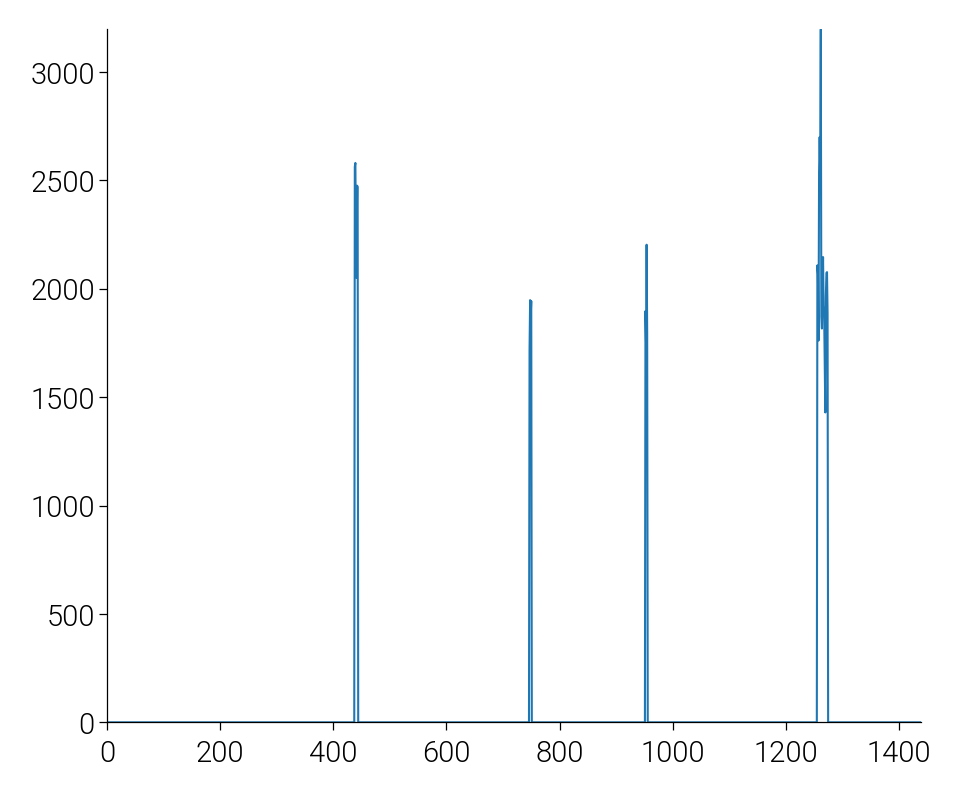

In [114]:
# hpb_uv_no compressor rpm range
rpm = hpb_uv['cmp_rpm [rpm]']
plt.plot(rpm)
valid_rpm = rpm[(rpm != 0) & (~rpm.isna())]
print(valid_rpm.mean())
max_rpm = valid_rpm.max()
min_rpm = valid_rpm.min()
print(max_rpm, min_rpm)
